# TEP 工业世界模型：从过程数据到控制规划

本教程以 Tennessee Eastman Process（TEP）为对象，构建一个动作条件的 JEPA 工业世界模型，并完成数据生成、表征学习、状态预测、反事实推演和闭环控制规划。

## TEP数据集概况

工具导入

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from tep import TEPSimulator

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data.data_gen import TEPDataGenerator, load_data_config
from engine.generation import build_generation_plan, generate_dataset
from utils.visualization import (
    plot_counterfactual_comparison,
    plot_key_variable_lines,
    plot_trajectory_overview,
    plot_variable_heatmap,
    plot_vector_bar,
)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind", font_scale=1.05)

轨迹生成

In [2]:
# 生成一条 1 小时、1 秒采样的正常闭环轨迹
seed = 42
simulator = TEPSimulator(random_seed=seed, backend="python")
result = simulator.simulate(duration_hours=1.0, record_interval=1)

# 设置列名
measurement_columns = [
    f"XMEAS({i}) {name}"
    for i, name in enumerate(simulator.get_measurement_names(), start=1)
]
action_columns = [
    f"XMV({i}) {name}"
    for i, name in enumerate(simulator.get_mv_names(), start=1)
]

# 在线可用的过程轨迹：时间、41 个测量变量和 12 个操纵变量
tep_trajectory = pd.concat(
    [
        pd.DataFrame({"time_hours": result.time}),
        pd.DataFrame(result.measurements, columns=measurement_columns),
        pd.DataFrame(result.manipulated_vars, columns=action_columns),
    ],
    axis=1,
)

# 50 维内部状态属于仿真器特权信息，单独保存
tep_states = pd.DataFrame(
    result.states,
    columns=[f"STATE({i})" for i in range(1, result.states.shape[1] + 1)],
)

print(f"轨迹采样点数: {len(tep_trajectory)}")
print(f"过程轨迹形状: {tep_trajectory.shape}")
print(f"内部状态形状: {tep_states.shape}")
print(f"是否触发停车: {result.shutdown}")
tep_trajectory.head()

轨迹采样点数: 3601
过程轨迹形状: (3601, 54)
内部状态形状: (3601, 50)
是否触发停车: False


,time_hours,XMEAS(1) A Feed (stream 1),XMEAS(2) D Feed (stream 2),XMEAS(3) E Feed (stream 3),XMEAS(4) A and C Feed (stream 4),XMEAS(5) Recycle Flow (stream 8),XMEAS(6) Reactor Feed Rate (stream 6),XMEAS(7) Reactor Pressure,XMEAS(8) Reactor Level,XMEAS(9) Reactor Temperature,...,XMV(3) A Feed Flow (stream 1),XMV(4) A and C Feed Flow (stream 4),XMV(5) Compressor Recycle Valve,XMV(6) Purge Valve (stream 9),XMV(7) Separator Pot Liquid Flow,XMV(8) Stripper Liquid Product Flow,XMV(9) Stripper Steam Valve,XMV(10) Reactor Cooling Water Flow,XMV(11) Condenser Cooling Water Flow,XMV(12) Agitator Speed
0,0.000000,0.250521,3664.038885,4509.268390,9.347742,26.902440,42.338849,2705.000000,75.000000,120.400000,...,24.643558,61.301921,22.210000,40.063747,38.100344,46.534156,47.445735,41.105813,18.113491,50.0
1,0.000278,0.250521,3664.038885,4509.268390,9.347742,26.902440,42.338849,2705.000000,75.000000,120.400000,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
2,0.000556,0.252494,3632.402846,4504.619387,9.275586,26.680047,42.599894,2704.521753,75.050384,120.403353,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
3,0.000833,0.253498,3673.271109,4471.339448,9.258792,27.000335,42.395277,2704.882467,75.199208,120.410779,...,26.263874,60.595414,22.210276,40.064106,38.100344,46.534156,47.445929,41.106100,18.114131,50.0
4,0.001111,0.255614,3641.960057,4436.460851,9.367677,27.140838,42.559449,2705.321432,75.428329,120.395700,...,25.978932,61.178694,22.271806,24.563023,32.351885,47.263719,47.363078,41.113061,18.077483,50.0


### XMEAS 传感器变量

XMEAS 数组维数: 2
XMEAS 形状: (3601, 41)
样本数: 3601
传感器变量数: 41


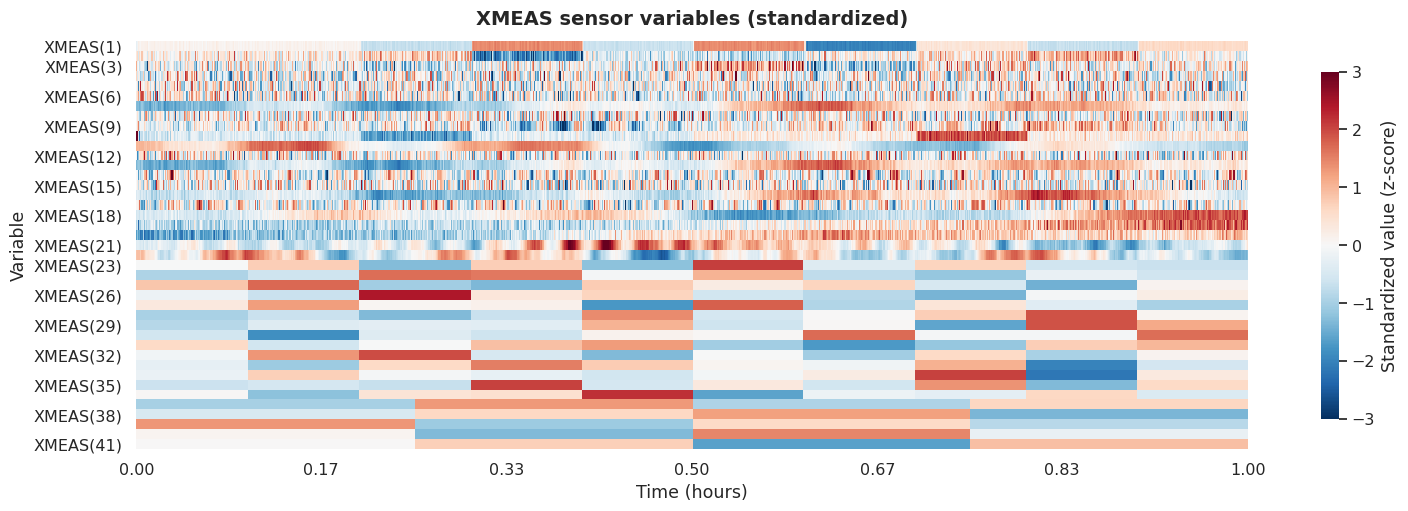

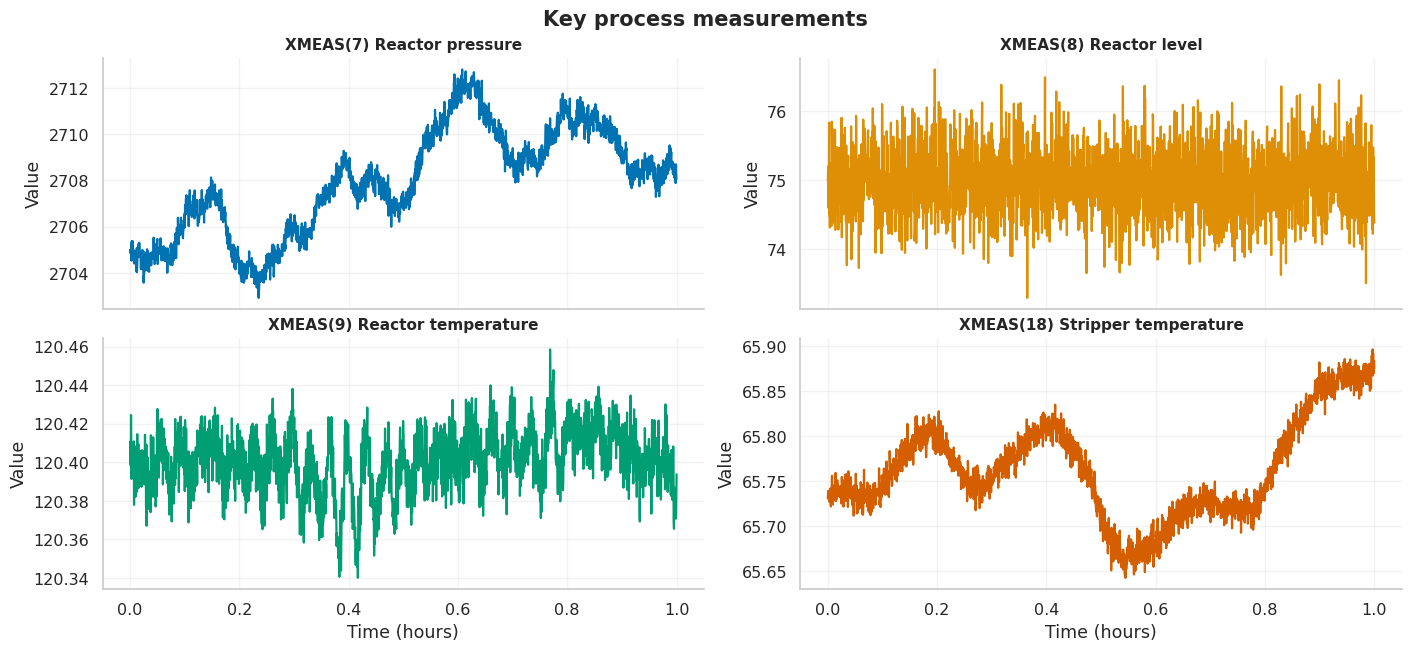

In [3]:
xmeas = pd.DataFrame(result.measurements, columns=measurement_columns)

print(f"XMEAS 数组维数: {result.measurements.ndim}")
print(f"XMEAS 形状: {result.measurements.shape}")
print(f"样本数: {result.measurements.shape[0]}")
print(f"传感器变量数: {result.measurements.shape[1]}")

plot_variable_heatmap(
    result.time,
    xmeas,
    labels=[f"XMEAS({i})" for i in range(1, xmeas.shape[1] + 1)],
    title="XMEAS sensor variables (standardized)",
)
plt.show()

plot_key_variable_lines(
    result.time,
    xmeas,
    indices=[6, 7, 8, 17],
    labels=[
        "XMEAS(7) Reactor pressure",
        "XMEAS(8) Reactor level",
        "XMEAS(9) Reactor temperature",
        "XMEAS(18) Stripper temperature",
    ],
    title="Key process measurements",
)
plt.show()

### XMV 操纵变量

XMV 数组维数: 2
XMV 形状: (3601, 12)
样本数: 3601
操纵变量数: 12


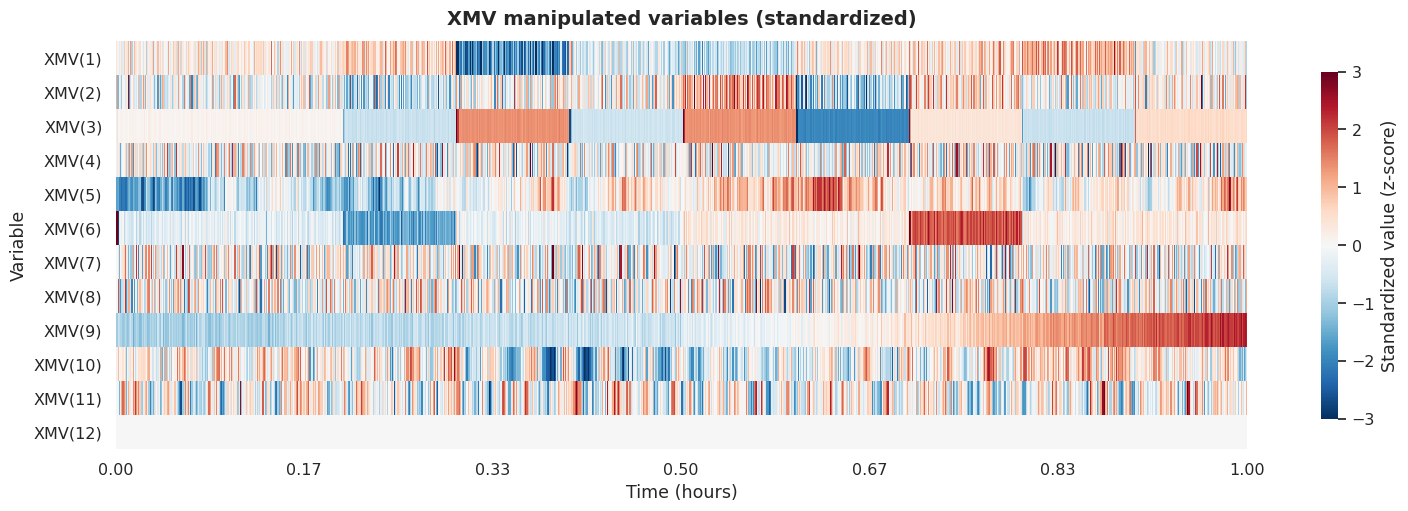

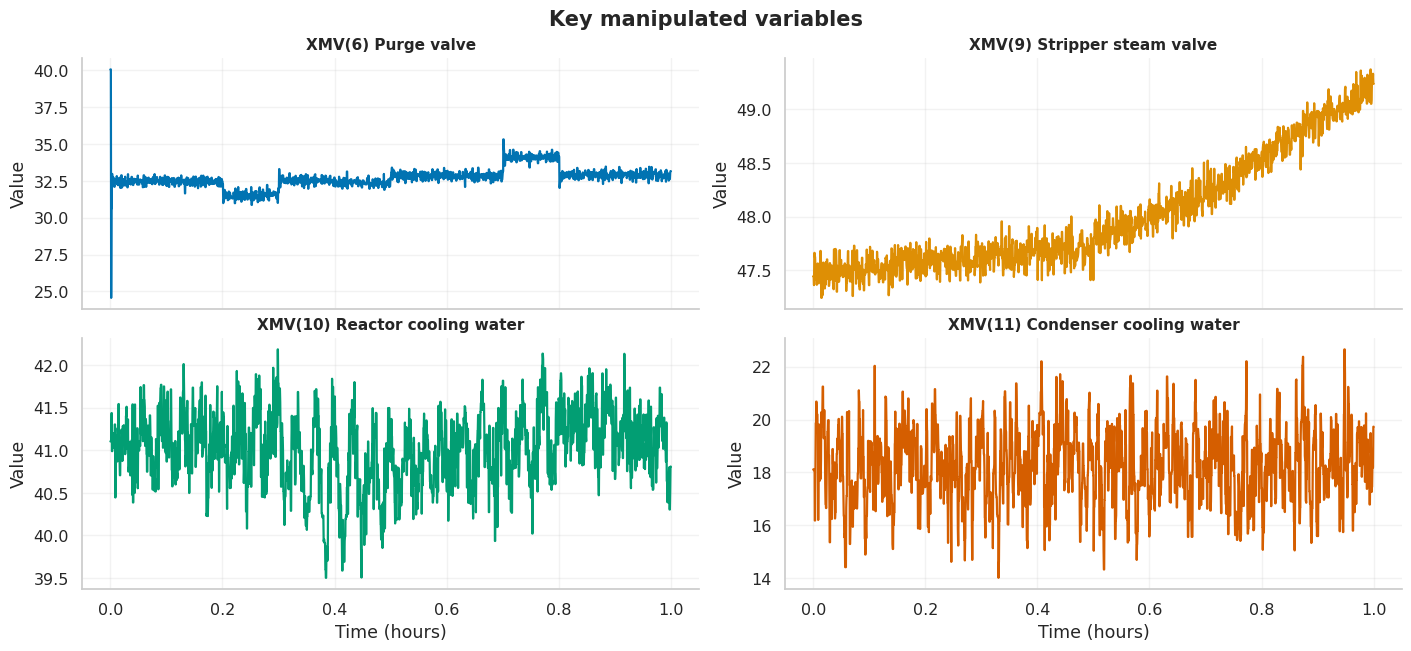

In [4]:
xmv = pd.DataFrame(result.manipulated_vars, columns=action_columns)

print(f"XMV 数组维数: {result.manipulated_vars.ndim}")
print(f"XMV 形状: {result.manipulated_vars.shape}")
print(f"样本数: {result.manipulated_vars.shape[0]}")
print(f"操纵变量数: {result.manipulated_vars.shape[1]}")

plot_variable_heatmap(
    result.time,
    xmv,
    labels=[f"XMV({i})" for i in range(1, xmv.shape[1] + 1)],
    title="XMV manipulated variables (standardized)",
)
plt.show()

plot_key_variable_lines(
    result.time,
    xmv,
    indices=[5, 8, 9, 10],
    labels=[
        "XMV(6) Purge valve",
        "XMV(9) Stripper steam valve",
        "XMV(10) Reactor cooling water",
        "XMV(11) Condenser cooling water",
    ],
    title="Key manipulated variables",
)
plt.show()

### 内部状态变量

内部状态数组维数: 2
内部状态形状: (3601, 50)
样本数: 3601
内部状态变量数: 50


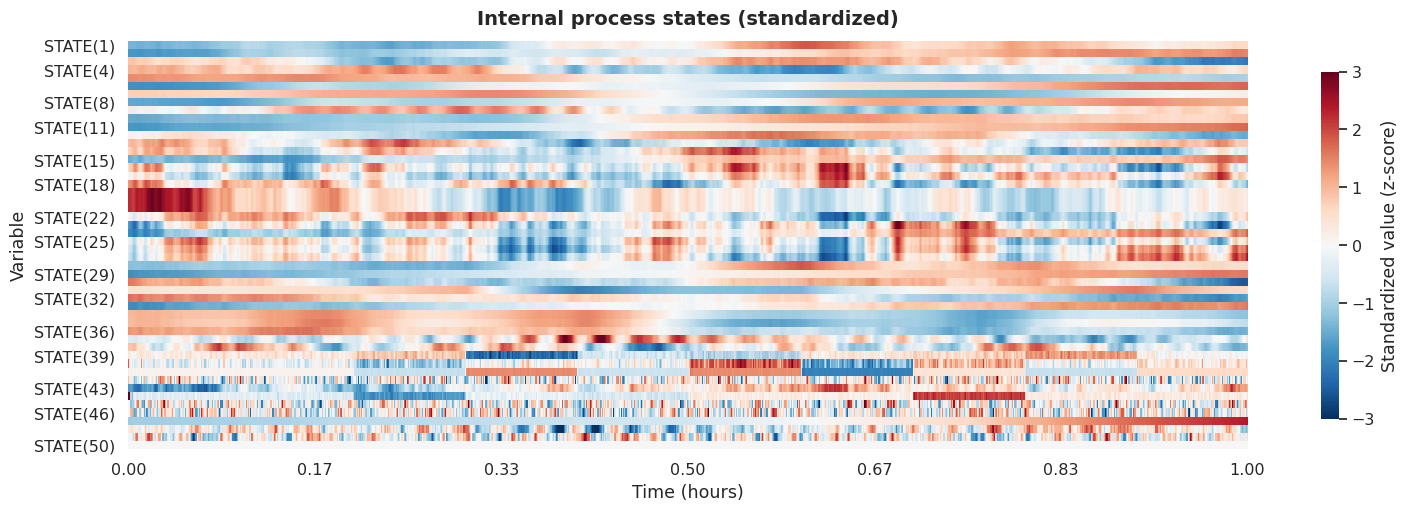

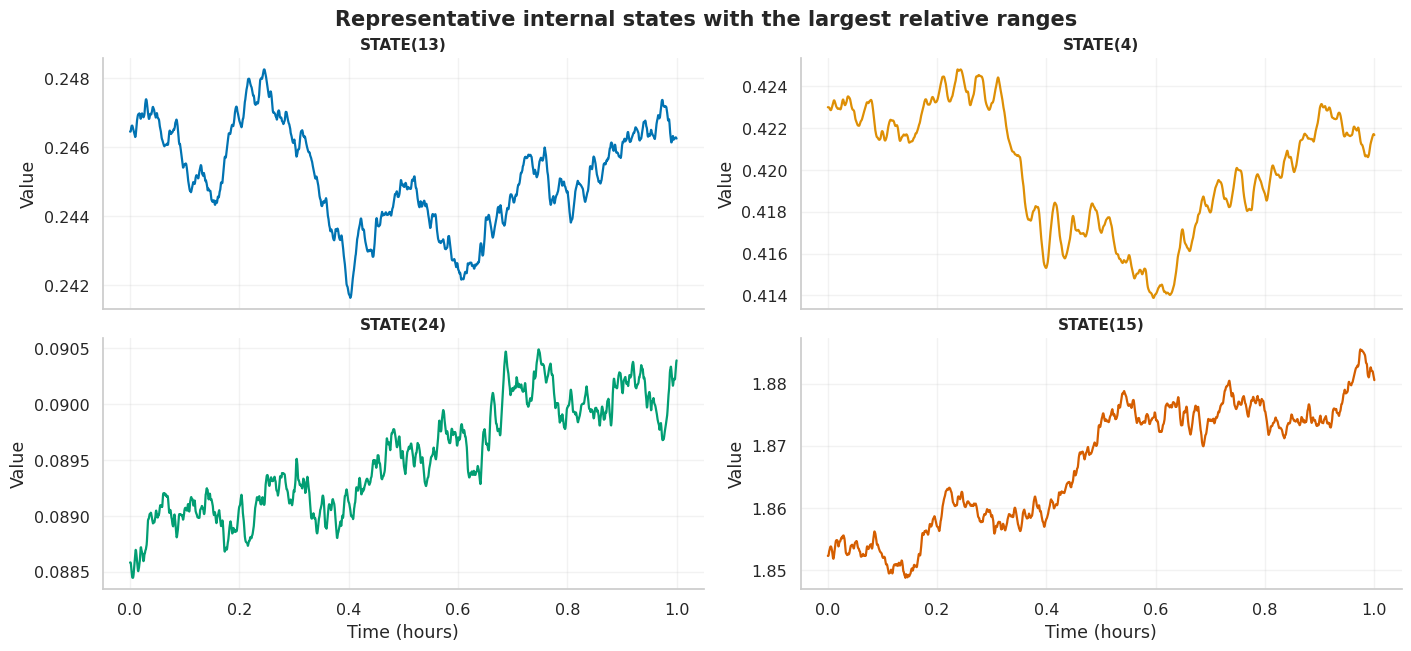

In [5]:
print(f"内部状态数组维数: {result.states.ndim}")
print(f"内部状态形状: {result.states.shape}")
print(f"样本数: {result.states.shape[0]}")
print(f"内部状态变量数: {result.states.shape[1]}")

plot_variable_heatmap(
    result.time,
    tep_states,
    labels=[f"STATE({i})" for i in range(1, tep_states.shape[1] + 1)],
    title="Internal process states (standardized)",
)
plt.show()

# 从前 38 个过程状态中选择相对变化幅度最大的 4 个，避免与末尾阀位状态重复
process_states = tep_states.iloc[:, :38]
relative_range = (process_states.max() - process_states.min()) / (process_states.mean().abs() + 1e-8)
key_state_indices = np.argsort(relative_range.to_numpy())[-4:][::-1]
key_state_labels = [process_states.columns[i] for i in key_state_indices]

plot_key_variable_lines(
    result.time,
    tep_states,
    indices=key_state_indices,
    labels=key_state_labels,
    title="Representative internal states with the largest relative ranges",
)
plt.show()

### 控制器设定值（调节器变量）

控制器类型: DecentralizedController
设定值数组维数: 1
设定值形状: (20,)
说明: 设定值是控制器参数，不包含时间维，因此不随时间变化。


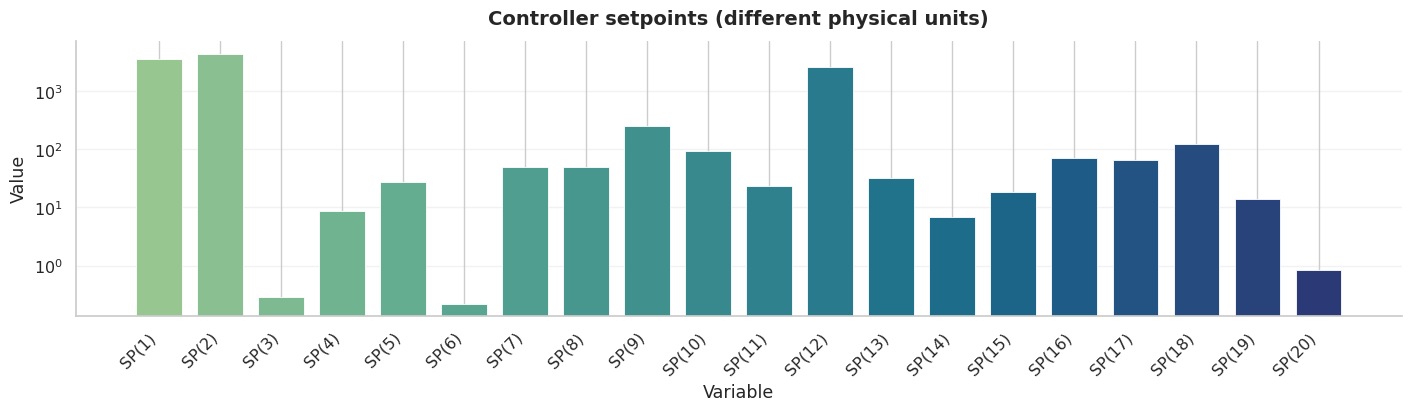

In [6]:
controller_setpoints = np.asarray(simulator.controller.setpoints)
setpoint_table = pd.DataFrame(
    {
        "controller": [f"SP({i})" for i in range(1, len(controller_setpoints) + 1)],
        "setpoint": controller_setpoints,
    }
)

print(f"控制器类型: {type(simulator.controller).__name__}")
print(f"设定值数组维数: {controller_setpoints.ndim}")
print(f"设定值形状: {controller_setpoints.shape}")
print("说明: 设定值是控制器参数，不包含时间维，因此不随时间变化。")

plot_vector_bar(
    controller_setpoints,
    labels=setpoint_table["controller"],
    title="Controller setpoints (different physical units)",
    log_scale=True,
)
plt.show()

## 世界模型的状态与动作

**观测状态**采用 `XMEAS(41) + XMV(12)`，共 53 维。XMEAS 描述过程测量，XMV 描述底层控制器实际施加的操纵量；模型使用一段历史观测推断未直接观测的过程和控制器状态。

**动作**采用可由上层规划器设定的 11 个外部 SP：

- 基础动作：SP13、SP14、SP15、SP17、SP18、SP19、SP20。
- 扩展动作：SP5、SP7、SP8、SP11，分别用于循环负荷、分离器液位、汽提塔液位和生产负荷调节。

SP1、SP2、SP3、SP4、SP6、SP9、SP10、SP16由串级控制器动态生成，属于内部控制器状态，不作为独立动作。规划器每次联合优化一组11维外部SP，在整个预测时域及本次执行段内保持不变，下一次反馈重规划时再更新。每次相对当前SP最多改变3个分量，各分量阶跃不超过允许范围的30%。CEM仅优化预测目标时刻的末端latent距离。

世界模型学习历史条件下的单步潜在状态转移：`历史观测/动作 + 当前SP → 下一模型步latent`；多步预测仅递归调用同一个predictor。

## 轨迹样本生成策略

| 类型 | 基础轨迹占比 | 动作设计 |
|---|---:|---|
| 固定SP | 5% | 全程保持，学习闭环基础动力学 |
| 单动作 | 40% | 多次调节，每次仅改变一个SP |
| 多动作 | 30% | 多次调节，至少一次同时改变多个SP |
| 干扰 | 15% | 单动作或多动作序列叠加IDV |
| 超限 | 5% | 应激序列，按实测越限或停车标注 |
| 工况切换 | 5% | 沿用工况切换样本 |

单动作、多动作及干扰中的基础动作共用片段采样：每个片段以70%概率连续6–9次逐模型步调节，其他片段为两次间隔1–3步的调节；片段之间保持6–12步。密集片段阶跃为SP允许范围的5%–15%，常规片段为10%–30%；共享动作上限不变。

反事实对仍额外生成。提前停车可能截断片段，因此检查实际连续变化次数，不能仅依据计划判断覆盖。

In [7]:
# 读取统一配置；辅助函数仅负责展示轨迹摘要和曲线。
from data.data_validation import action_change_counts
data_config = load_data_config(project_root / "configs/config.yaml")
example_plans = build_generation_plan(data_config, num_trajectories=20, counterfactual_pairs=0)
example_configs = {
    name: next(plan["config"] for plan in example_plans if plan["scenario_type"] == name)
    for name in data_config["generation"]["scenario_proportions"]
}

def show_trajectory(trajectory, config, title):
    active_idvs = np.flatnonzero(trajectory.disturbances.max(axis=0)) + 1
    counts = action_change_counts(trajectory.actions, trajectory.metadata["initial_action"])
    summary = pd.DataFrame([{
        "actual action events": int(np.count_nonzero(counts)),
        "multi-SP events": int(np.count_nonzero(counts >= 2)),
        "limit violations": str(trajectory.metadata["limit_violations"]),
        "type": trajectory.trajectory_type,
        "outcome": trajectory.outcome,
        "duration (h)": round(float(trajectory.time[-1]), 3),
        "transitions": len(trajectory.actions),
        "observation shape": str(trajectory.observations.shape),
        "action shape": str(trajectory.actions.shape),
        "changed SPs": str(list(trajectory.metadata["changed_action_sp_numbers"])),
        "active IDVs": str(active_idvs.tolist()),
        "shutdown": trajectory.shutdown,
    }])
    display(summary)
    plot_trajectory_overview(
        trajectory,
        action_sp_numbers=config["action_sp_numbers"],
        title=title,
    )
    plt.show()

### 1. 固定SP轨迹

预热至稳定工况后，所有外部SP保持不变，用于展示正常闭环运行下的基础动力学。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,0,0,{'XMEAS9': 0},fixed_sp,near_boundary,1.583,5700,"(5701, 53)","(5700, 11)",[],[],False


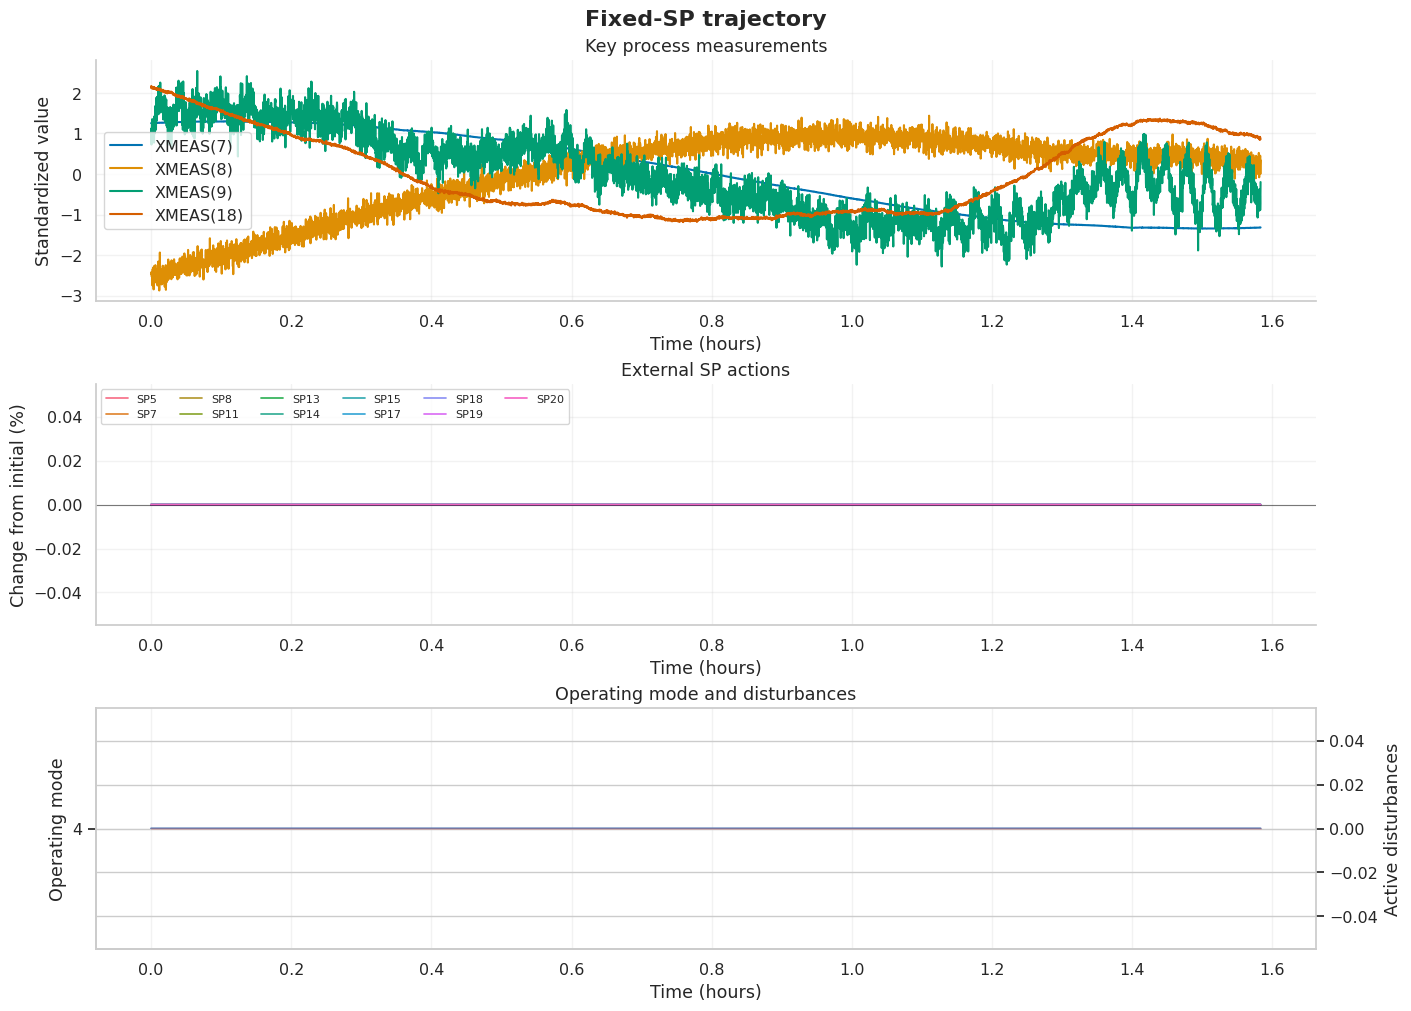

In [8]:
fixed_config = example_configs["fixed_sp"]
fixed_trajectory = TEPDataGenerator(fixed_config, initialize=False).generate_trajectory()
show_trajectory(fixed_trajectory, fixed_config, "Fixed-SP trajectory")


### 2. 单动作轨迹

整条轨迹有多次调节，每次只改变一个SP；不同事件可以调节不同SP。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,12,0,{'XMEAS9': 0},action,normal,3.083,11100,"(11101, 53)","(11100, 11)","[5, 7, 8, 13, 14, 15, 17, 19, 20]",[],False


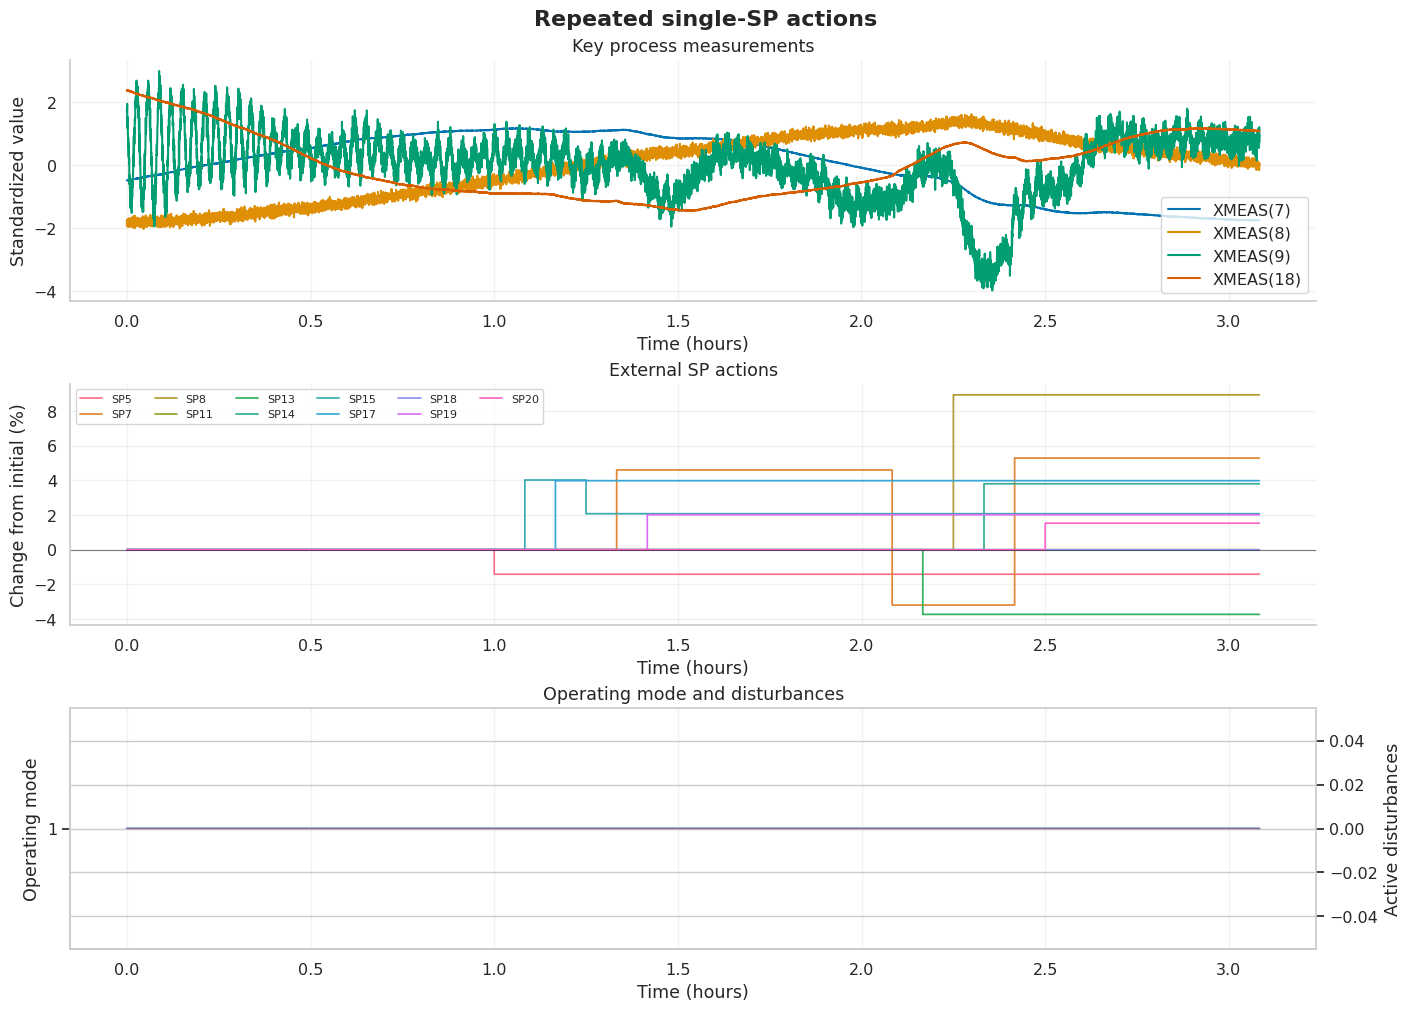

In [9]:
single_action_config = example_configs["single_action"]
single_action_trajectory = TEPDataGenerator(single_action_config, initialize=False).generate_trajectory()
show_trajectory(single_action_trajectory, single_action_config, "Repeated single-SP actions")


### 3. 多动作轨迹

整条轨迹包含多次调节，首个事件同时改变至少两个SP，后续事件可以改变一个或多个SP。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,25,16,{'XMEAS9': 0},action,normal,6.583,23700,"(23701, 53)","(23700, 11)","[5, 7, 8, 11, 13, 14, 15, 17, 18, 19, 20]",[],False


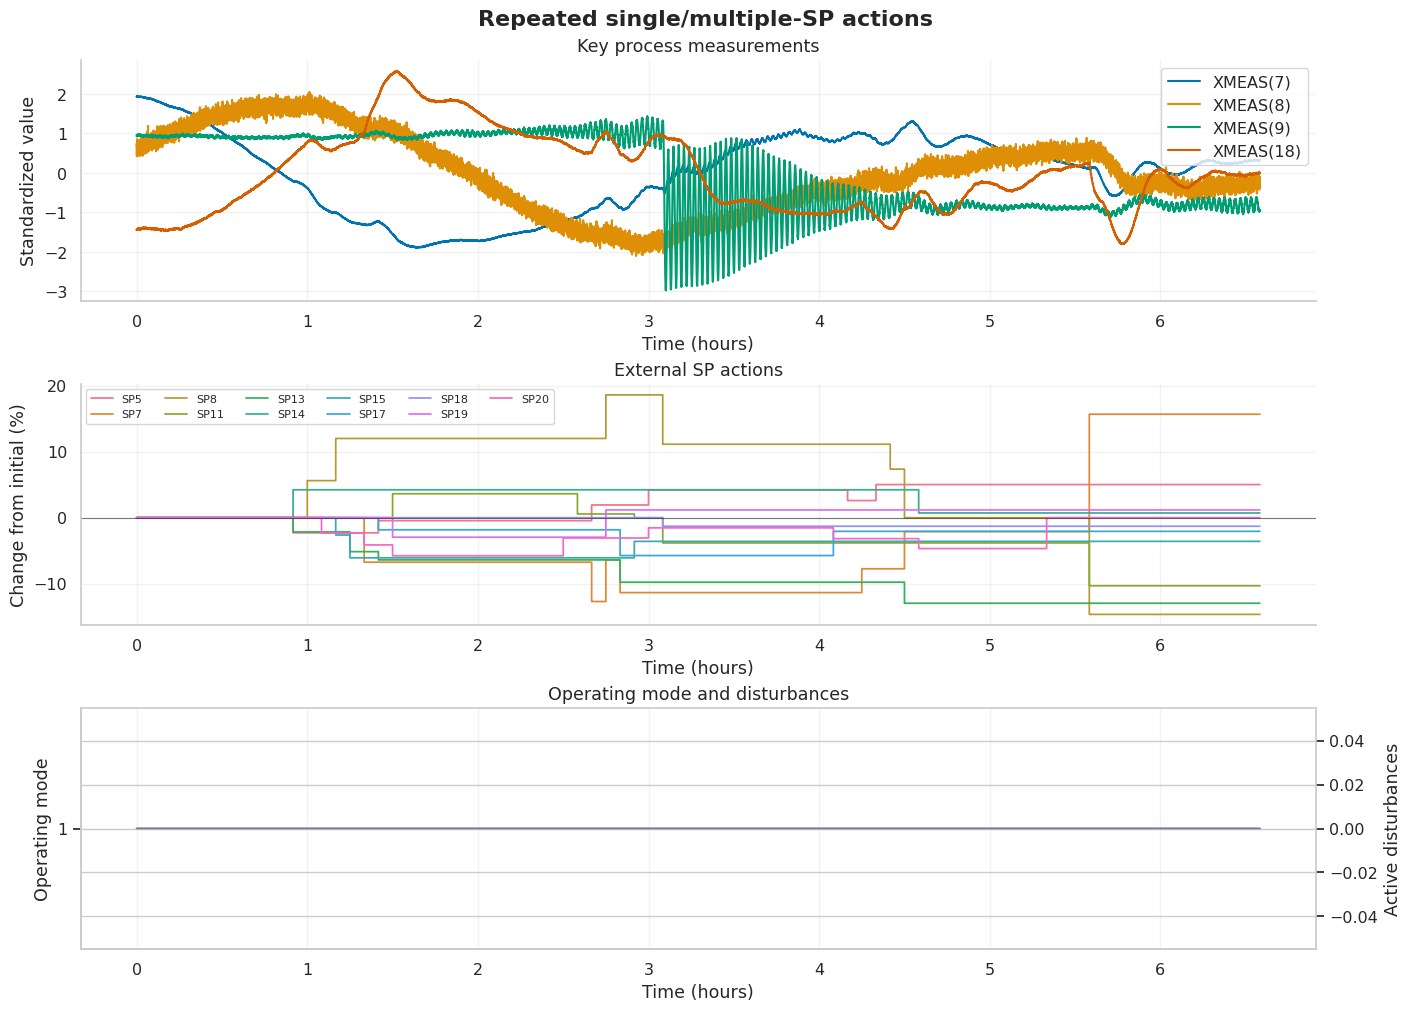

In [10]:
multi_action_config = example_configs["multi_action"]
multi_action_trajectory = TEPDataGenerator(multi_action_config, initialize=False).generate_trajectory()
show_trajectory(multi_action_trajectory, multi_action_config, "Repeated single/multiple-SP actions")


### 4. 干扰与恢复轨迹

随机选择单动作或多动作序列，再叠加IDV开启与关闭事件，保留基础动作类型。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,19,15,{'XMEAS9': 0},disturbance,normal,4.583,16500,"(16501, 53)","(16500, 11)","[5, 7, 8, 11, 13, 14, 15, 17, 18, 19, 20]","[4, 9]",False


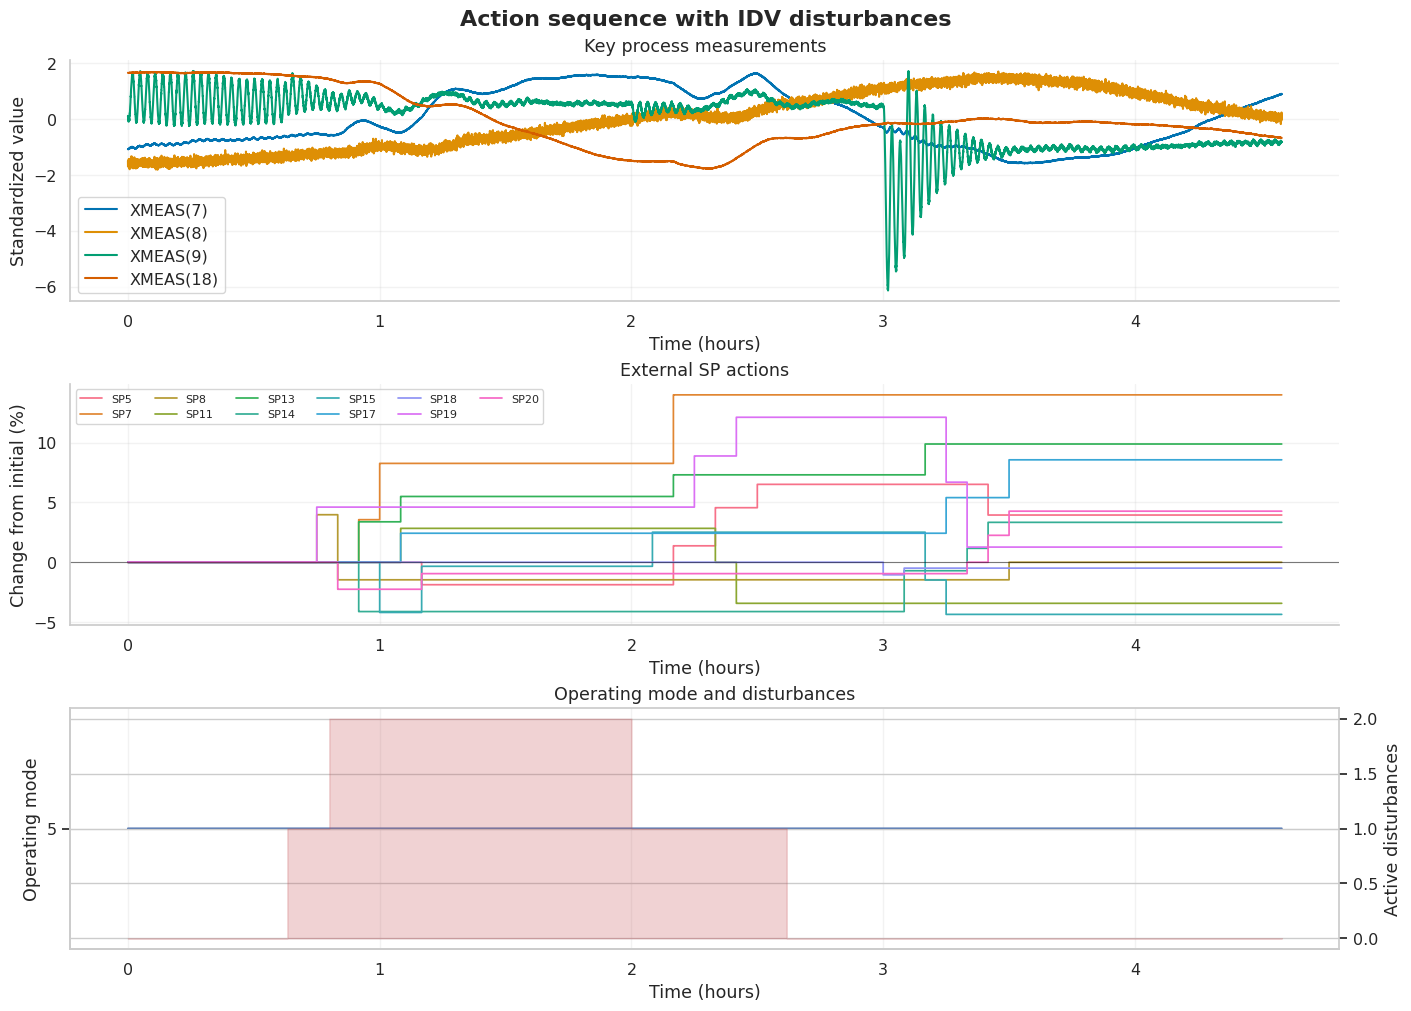

In [11]:
disturbance_config = example_configs["disturbance"]
disturbance_trajectory = TEPDataGenerator(disturbance_config, initialize=False).generate_trajectory()
show_trajectory(disturbance_trajectory, disturbance_config, "Action sequence with IDV disturbances")


### 5. 超限轨迹

按配置逐步调节并保持应激SP目标。默认SP18目标130°C，XMEAS9实验软边界为110–129°C；该边界是实验设定。是否越界依据每秒测量值和仿真器停车结果，不把应激动作意图当作已发生超限。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,2,2,{'XMEAS9': 10922},action,limit_exceeded,4.25,15300,"(15301, 53)","(15300, 11)","[5, 18]",[],False


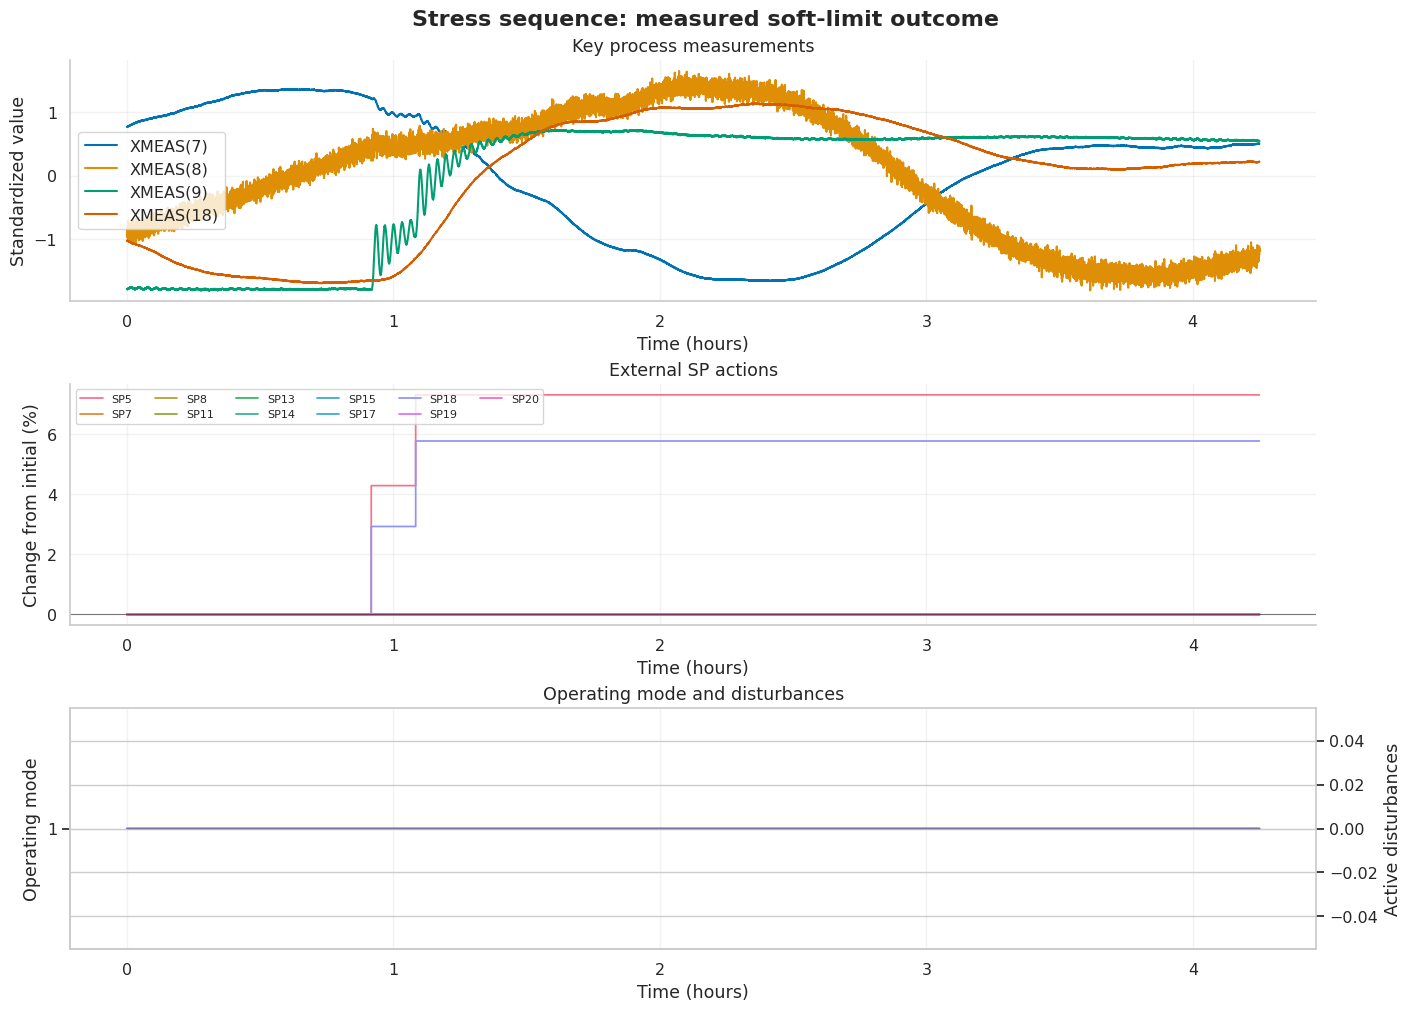

In [12]:
limit_exceeded_config = example_configs["boundary_action"]
limit_exceeded_trajectory = TEPDataGenerator(limit_exceeded_config, initialize=False).generate_trajectory()
show_trajectory(limit_exceeded_trajectory, limit_exceeded_config, "Stress sequence: measured soft-limit outcome")


### 6. 反事实轨迹对比

保持相同种子、初始工况、预热及记录时长，比较固定SP与连续单动作序列；批量生成的同源轨迹对始终划入同一数据集合。

初始观测最大差异: 0.000e+00


,variable,reference final,intervention final,counterfactual difference
0,XMEAS7 reactor pressure,2395.802,2423.023,27.221
1,XMEAS8 reactor level,66.427,69.963,3.536
2,XMEAS9 reactor temperature,122.926,122.919,-0.007
3,XMEAS38 product E,0.891,0.993,0.102


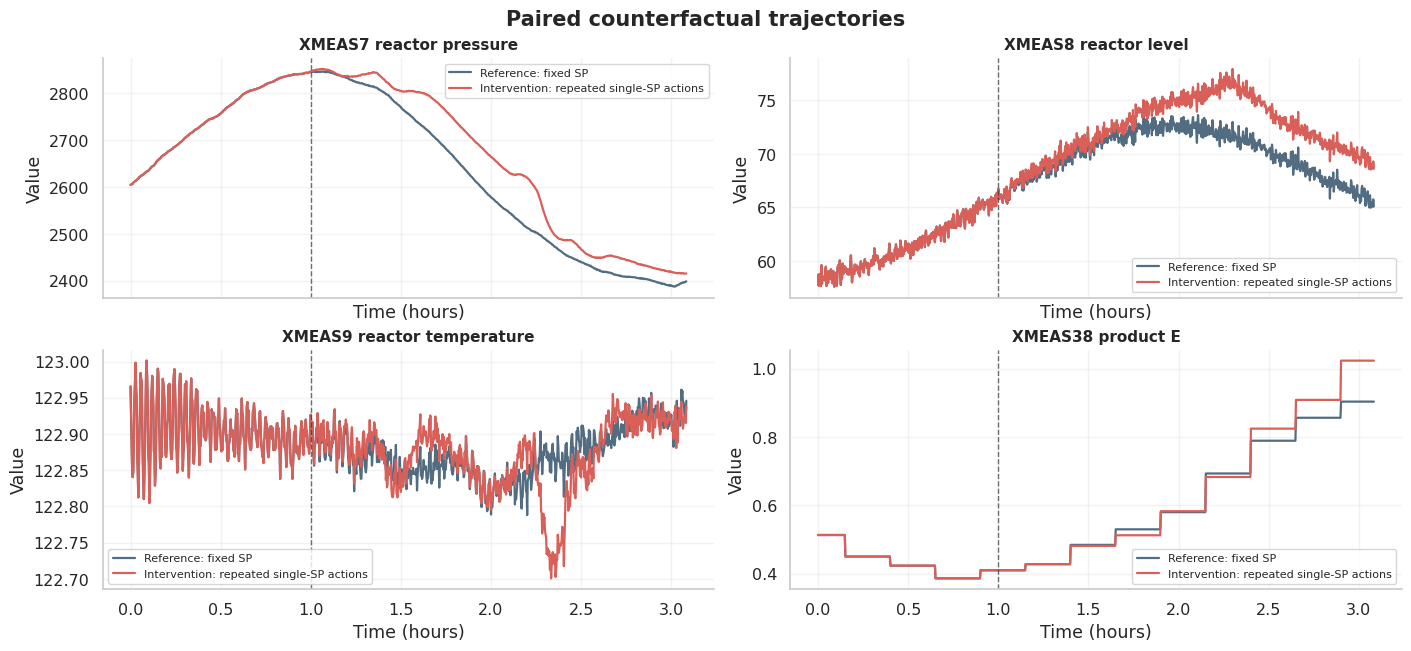

Comparison duration (h): 3.0833333333338153
Stopped at first trajectory end: False


In [13]:
# 保持相同种子、工况和预热过程，仅移除动作事件作为参考。
counterfactual_reference_config = {
    **single_action_config,
    "action_events": [],
}
counterfactual_reference = TEPDataGenerator(
    counterfactual_reference_config, initialize=False
).generate_trajectory()
counterfactual_intervention = single_action_trajectory

counterfactual_variables = {
    "XMEAS7 reactor pressure": 6,
    "XMEAS8 reactor level": 7,
    "XMEAS9 reactor temperature": 8,
    "XMEAS38 product E": 37,
}
counterfactual_comparison, counterfactual_figure, _ = (
    plot_counterfactual_comparison(
        counterfactual_reference,
        counterfactual_intervention,
        counterfactual_variables,
        reference_label="Reference: fixed SP",
        intervention_label="Intervention: repeated single-SP actions",
        intervention_time_hours=single_action_config["action_events"][0]["time_hours"],
    )
)
initial_difference = counterfactual_comparison.attrs[
    "initial_observation_max_difference"
]
print(f"初始观测最大差异: {initial_difference:.3e}")
display(counterfactual_comparison.round(3))
plt.show()

print("Comparison duration (h):", counterfactual_comparison.attrs["comparison_duration_hours"])
print("Stopped at first trajectory end:", counterfactual_comparison.attrs["truncated_at_first_end"])


### 7. 工况切换轨迹

沿用额外的工况切换样本。切换事件也与模型时间网格对齐，保留切换后的真实过程响应。

,actual action events,multi-SP events,limit violations,type,outcome,duration (h),transitions,observation shape,action shape,changed SPs,active IDVs,shutdown
0,1,0,{'XMEAS9': 0},action,normal,6.0,21600,"(21601, 53)","(21600, 11)",[18],[],False


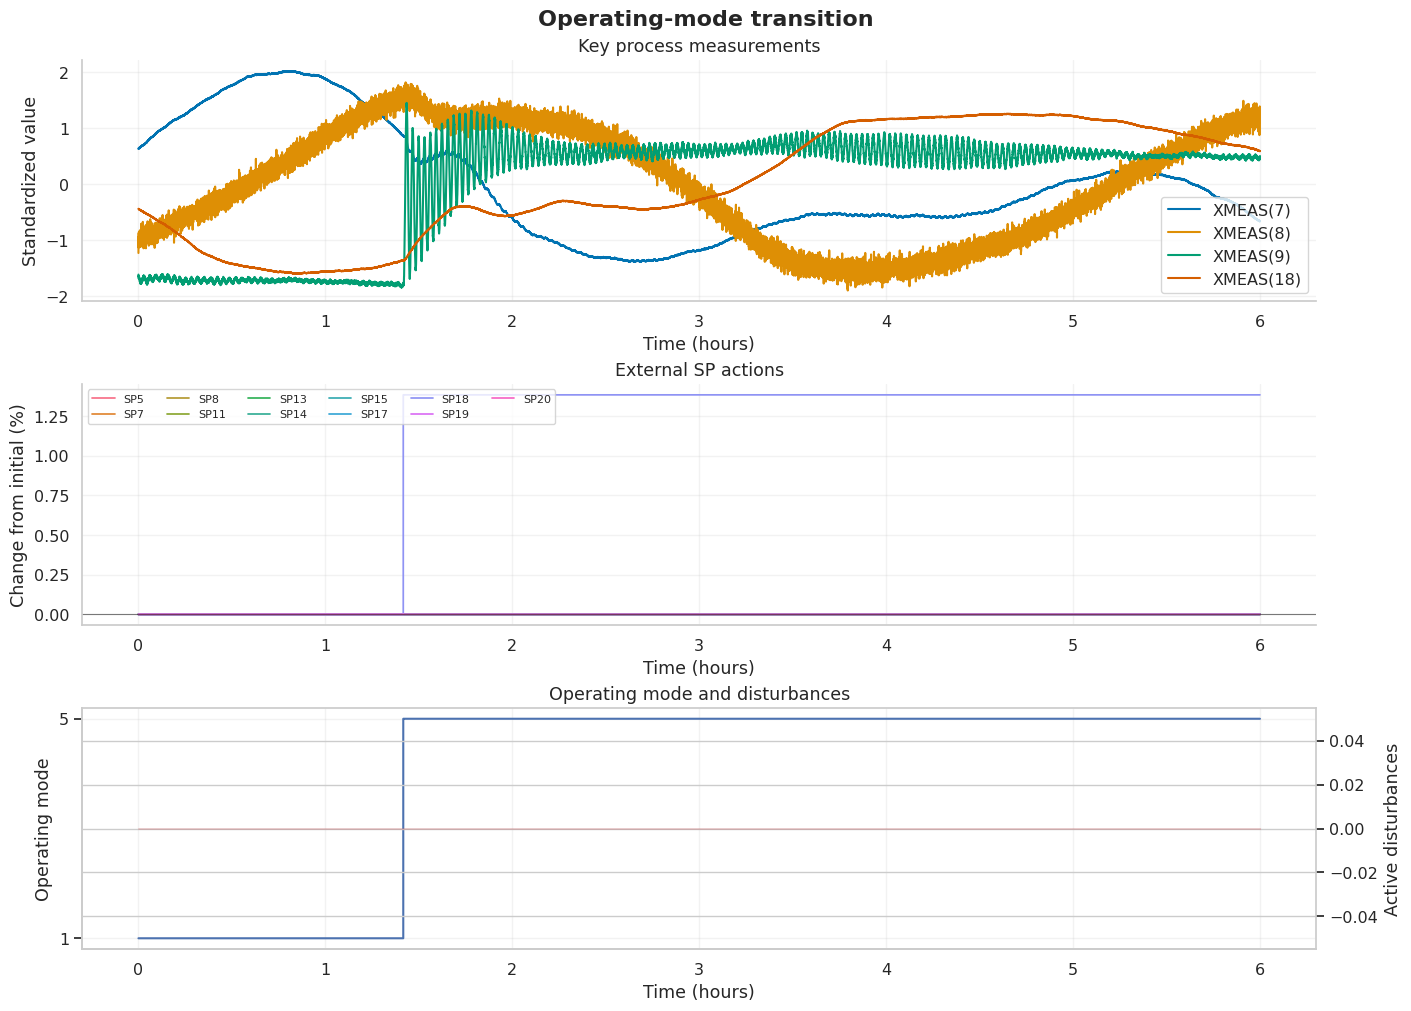

In [14]:
mode_switch_config = example_configs["mode_switch"]
mode_switch_trajectory = TEPDataGenerator(mode_switch_config, initialize=False).generate_trajectory()
show_trajectory(mode_switch_trajectory, mode_switch_config, "Operating-mode transition")


## 批量训练数据生成

按配置生成1400条基础轨迹及60对反事实轨迹，写入固定的 `datasets/tep_latest`。训练、验证、测试按轨迹组划分，反事实对不跨集合。

模型步默认5分钟，原始仿真记录仍为1秒。密集片段连续6–9步调节；稀疏片段内间隔5–15分钟，片段之间保持30–60分钟。参数统一读取 `generation.action`，改变模型步后物理时长随之改变。

生成后检查实际动作次数、最长连续变化次数、密集片段覆盖率及停车/越限情况。训练前进一步统计各场景在训练窗口中的动作变化占比和连续H步变化窗口数量。

运行下方单元会按配置完整生成数据，并在 `overwrite=true` 时替换 `datasets/tep_latest`。数据是否变化取决于配置、种子及生成代码；若数据改变，验证/测试轨迹与规划任务也可能改变。已有结果对应的数据清单指纹保存在评估记录中；选参研究应固定数据与任务，跳过本生成单元。

In [15]:
from data.data_validation import audit_dataset

# 不传数量参数，按config.yaml执行正式全量生成并显示总体进度。
data_config = load_data_config(project_root / "configs/config.yaml")
full_output_dir = (
    project_root / data_config["output_dir"]
    / data_config["generation"]["dataset_name"]
)
full_result = generate_dataset(
    data_config,
    output_dir=full_output_dir,
    show_progress=True,
)

# 只展示一次数据集级质量审计，不逐条打印轨迹质量门。
dataset_audit = audit_dataset(full_output_dir)
display(pd.DataFrame([full_result["summary"]]))
print(f"数据目录：{full_result['output_dir']}")
print(f"审计通过：{dataset_audit['accepted']}")
print(f"各划分缺失动作：{dataset_audit['missing_actions_by_split']}")
print(f"反事实配对错误：{dataset_audit['counterfactual_pair_errors']}")
print(f"清单指纹一致：{dataset_audit['fingerprint_matches']}")
records_frame = pd.DataFrame(full_result["records"])
records_frame["mean_interval_minutes"] = records_frame["actual_action_event_steps"].map(
    lambda steps: float(np.mean(np.diff(steps)) / 60) if len(steps) > 1 else np.nan
)
display(records_frame.groupby(["split", "scenario_type"]).agg(
    trajectories=("trajectory_id", "count"),
    actual_events=("action_event_count", "mean"),
    multi_sp_events=("multi_sp_event_count", "mean"),
    longest_change_run=("max_consecutive_action_changes", "max"),
    dense_trajectory_rate=("max_consecutive_action_changes", lambda values:
        (values >= data_config["generation"]["action"]["burst_event_count"][0]).mean()),
    mean_interval_minutes=("mean_interval_minutes", "mean"),
    complete_pattern_rate=("action_pattern_complete", "mean"),
    observed_unsafe_rate=("observed_unsafe", "mean"),
))


Generating TEP trajectories:   0%|          | 0/1520 [00:00<?, ?trajectory/s]

,trajectory_count,total_transitions,total_duration_hours,scenario_counts,outcome_counts,action_pattern_incomplete_count,boundary_attempt_count,boundary_observed_unsafe_count,mean_action_event_count,mean_action_interval_minutes,split_counts,mode_counts,action_counts,missing_action_sp_numbers,action_coverage_ratio,idv_counts,model_step_seconds,manifest_sha256,config_sha256
0,1520,23429948,6508.318889,"{'single_action': 560, 'disturbance': 210, 'mu...","{'normal': 865, 'near_boundary': 159, 'shutdow...",34,70,70,13.755263,10.154539,"{'train': 1077, 'test': 228, 'validation': 215}","{'1': 396, '4': 370, '2': 399, '5': 355}","{'5': 999, '7': 1014, '8': 1009, '11': 1006, '...",[],1.0,"{'17': 10, '3': 16, '10': 11, '18': 14, '11': ...",300,68546d3deeacc5e5cd9d871bf0643c0396092c69bbcc1a...,af7805f1913e7491d9dbc57063148c602776bb83279e53...


数据目录：/home/lsx/workspace/TWM/datasets/tep_latest
审计通过：True
各划分缺失动作：{'test': [], 'train': [], 'validation': []}
反事实配对错误：[]
清单指纹一致：True


trajectories  actual_events  \
split      scenario_type                                              
test       boundary_action                        12       2.000000   
           counterfactual_intervention            13      12.538462   
           counterfactual_reference               13       0.000000   
           disturbance                            29      20.965517   
           fixed_sp                                7       0.000000   
           mode_switch                             7       1.000000   
           multi_action                           59      21.271186   
           single_action                          88      11.943182   
train      boundary_action                        56       1.982143   
           counterfactual_intervention            38      12.947368   
           counterfactual_reference               38       0.000000   
           disturbance                           151      21.556291   
           fixed_sp                               52       0.000000   
           mode_switch                            50       0.980000   
           multi_action                          296      19.868243   
           single_action                         396      12.828283   
validation boundary_action                         2       1.000000   
           counterfactual_intervention             9      13.777778   
           counterfactual_reference                9       0.000000   
           disturbance                            30      16.466667   
           fixed_sp                               11       0.000000   
           mode_switch                            13       1.000000   
           multi_action                           65      20.307692   
           single_action                          76      12.881579   

                                        multi_sp_events  longest_change_run  \
split      scenario_type                                                      
test       boundary_action                     1.916667                   2   
           counterfactual_intervention         0.000000                   9   
           counterfactual_reference            0.000000                   0   
           disturbance                         5.655172                   9   
           fixed_sp                            0.000000                   0   
           mode_switch                         0.000000                   1   
           multi_action                       14.406780                   9   
           single_action                       0.000000                   9   
train      boundary_action                     1.839286                   2   
           counterfactual_intervention         0.000000                   9   
           counterfactual_reference            0.000000                   0   
           disturbance                         8.483444                   9   
           fixed_sp                            0.000000                   0   
           mode_switch                         0.000000                   1   
           multi_action                       13.726351                   9   
           single_action                       0.000000                   9   
validation boundary_action                     1.000000                   1   
           counterfactual_intervention         0.000000                   9   
           counterfactual_reference            0.000000                   0   
           disturbance                         7.033333                   9   
           fixed_sp                            0.000000                   0   
           mode_switch                         0.000000                   1   
           multi_action                       13.830769                   9   
           single_action                       0.000000                   9   

                                        dense_trajectory_rate  \
split      scenario_type                                        
test    

## TEP-LeWM 世界模型

当前模型步为5分钟，历史长度为12步；规划采用时域对齐与SP段内保持，目标偏移18步、执行预算20步，每执行1步（5分钟）后重规划。模型仍按验证单步prediction loss选模；规划可以直接加载兼容的已有检查点。本次仅更新规划实现，未运行本地实验；具体模型、数据和评估配置以检查点元数据及结果目录中的 `provenance.json` 为准。

模型复用 LeWorldModel（LeWM）的端到端联合嵌入预测思想，并针对TEP的低维连续过程数据进行适配。模型不直接处理图像，而是在潜在空间学习“当前过程状态 + SP动作 → 下一过程状态”的动力学。

| 模块 | TEP适配 | 作用 |
|---|---|---|
| 状态输入 | `XMEAS(41) + XMV(12)`，共53维 | 描述可观测过程状态 |
| 动作输入 | 11个可独立设置的SP | 描述外部控制动作 |
| 状态编码器 | MLP | 将53维状态映射为128维潜在表示 |
| 动作编码器 | LeWM Embedder | 将SP动作映射为条件表示 |
| 动力学预测器 | 动作条件因果Transformer | 根据状态—动作历史预测下一潜在状态 |
| 防坍塌约束 | SIGReg | 约束潜在表示接近各向同性高斯分布 |

1. **轨迹长度**：仿真器每秒记录一次。当前固定SP轨迹为60–180分钟，单动作轨迹为180–300分钟，多动作和干扰轨迹为240–480分钟；提前停车的轨迹以实际长度为准。
2. **轨迹切分**：先按完整轨迹组划分训练、验证和测试集，再在各轨迹内切窗，反事实对不跨集合。采样和滑窗均为一个模型步，默认300秒。每个窗口包含13个观测和12个动作，覆盖60分钟；模型步长为Δ分钟、轨迹长度为D分钟时，样本数为 `max(0, floor(D / Δ) - history_size + 1)`。
3. **时间对齐**：输入为 `observations: (13, 53)` 和 `actions: (12, 11)`；`actions[t]` 在 `observations[t]` 到 `observations[t+1]` 的整个模型步区间内保持不变，默认5分钟。加载轨迹时检查这一条件。所有变量只使用训练集统计量标准化。
4. **训练目标**：每个历史位置预测下一步latent，输出 `(B, 12, 128)`，与真实观测编码得到的下一步latent计算MSE，并加上SIGReg。训练和逐轮验证均只计算单步预测，最佳检查点由验证单步prediction loss选择。
5. **规划推演**：预测latent反馈给同一个单步predictor，递归执行H步；H由距目标的剩余模型步数确定，最小为1，与训练历史长度独立。每个候选SP在整个预测时域保持不变。多步推演误差仅用于训练后的评估。

In [16]:
# 建模与训练相关依赖
import os
import subprocess
import torch
import yaml
from torch.utils.data import DataLoader

from data.data_process import TEPWindowDataset, compute_normalization
from data.data_validation import model_step_seconds
from engine.evaluation import (
    evaluate_latent_prediction,
    predict_latent_trajectory,
)
from engine.planning_evaluation import evaluate_planning_tasks
from engine.training import train_world_model
from models.model import build_tep_lewm
from utils.evaluation_visualization import (
    plot_latent_prediction_evaluation,
    plot_planning_case,
    plot_latent_trajectory_comparison,
)
from utils.training_visualization import plot_training_history

In [17]:
# 第一步：读取模型配置并实例化TEP-LeWM。
with open(project_root / "configs/config.yaml", encoding="utf-8") as file:
    project_config = yaml.safe_load(file)

model_config = project_config["model"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_tep_lewm(model_config).to(device)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"运行设备：{device}")
print(f"模型参数量：{parameter_count:,}")

运行设备：cuda
模型参数量：1,557,764


### 数据预处理与DataLoader

归一化均值和标准差只从训练集计算，避免验证集信息泄漏。随后按照配置将每条轨迹切分为13个状态和12个动作组成的因果窗口，预览训练与验证窗口及一个样本批次；训练接口统一创建实际使用的DataLoader。窗口内12个相邻转移均接受单步监督，不要求额外的多步未来序列。

In [18]:
# 训练始终读取配置中的latest数据集，避免时间戳目录与配置脱节。
training_config = project_config["training"]
dataset_dir = project_root / training_config["dataset_dir"]
sample_stride = model_step_seconds(project_config["data"])

# 只根据训练轨迹计算53维状态和11维动作的标准化参数。
normalization = compute_normalization(
    dataset_dir,
    split=training_config["train_split"],
    sample_stride_steps=sample_stride,
)

dataset_options = {
    "stats": normalization,
    "history_size": model_config["history_size"],
    "sample_stride_steps": sample_stride,
    "preload": False,
}
train_dataset = TEPWindowDataset(
    dataset_dir, training_config["train_split"], **dataset_options
)
validation_dataset = TEPWindowDataset(
    dataset_dir, training_config["validation_split"], **dataset_options
)

# 检查数据集规模以及一个真实训练批次的输入维度。
dataset_summary = pd.DataFrame(
    [train_dataset.describe(), validation_dataset.describe()],
    index=["train", "validation"],
)
display(dataset_summary)
first_batch = next(iter(DataLoader(
    train_dataset, batch_size=training_config["batch_size"], shuffle=False,
)))
print(f"数据目录：{dataset_dir}")
print(f"模型步长：{sample_stride / 60:g}分钟；训练窗口：{model_config['history_size'] * sample_stride / 60:g}分钟")
print(f"状态批次：{tuple(first_batch['observations'].shape)}")
print(f"动作批次：{tuple(first_batch['actions'].shape)}")
print(f"单步目标观测：{tuple(first_batch['observations'][:, 1:].shape)}")
# Count actual action-change exposure with the same overlapping windows used for training.
coverage_rows = []
history = model_config["history_size"]
# 动作覆盖诊断使用预测评估的最长时域，不依赖规划剩余时间。
horizon = max(project_config["evaluation"]["horizons"])
for split, dataset in (("train", train_dataset), ("validation", validation_dataset)):
    for record in dataset.records:
        steps = int(record["transitions"]) // sample_stride
        events = np.asarray(record["actual_action_event_steps"], dtype=int) // sample_stride
        events = events[events < steps]
        weights = np.maximum(0, np.minimum(events, steps - history)
                             - np.maximum(0, events - history + 1) + 1)
        flags = np.zeros(steps, dtype=int)
        flags[events] = 1
        counts = (np.convolve(flags, np.ones(horizon, dtype=int), mode="valid")[history - 1:]
                  if steps >= history + horizon - 1 else np.array([], dtype=int))
        coverage_rows.append({
            "split": split, "scenario_type": record["scenario_type"],
            "prediction_targets": max(0, steps - history + 1) * history,
            "changed_targets": int(weights.sum()),
            "horizon_windows": len(counts),
            "fully_changed_windows": int(np.count_nonzero(counts == horizon)),
        })
coverage = pd.DataFrame(coverage_rows).groupby(["split", "scenario_type"]).sum()
coverage["changed_target_fraction"] = coverage["changed_targets"] / coverage["prediction_targets"].replace(0, np.nan)
coverage["fully_changed_window_fraction"] = coverage["fully_changed_windows"] / coverage["horizon_windows"].replace(0, np.nan)
print(f"Actual action coverage; consecutive horizon = {horizon} model steps")
display(coverage.round(4))


,trajectory_count,window_count,history_size,sample_stride_seconds
train,1077,43930,12,300
validation,215,8232,12,300


数据目录：/home/lsx/workspace/TWM/datasets/tep_latest
模型步长：5分钟；训练窗口：60分钟
状态批次：(256, 13, 53)
动作批次：(256, 12, 11)
单步目标观测：(256, 12, 53)
Actual action coverage; consecutive horizon = 6 model steps


prediction_targets  changed_targets  \
split      scenario_type                                                      
train      boundary_action                           40212             1211   
           counterfactual_intervention               14400             5513   
           counterfactual_reference                  16464                0   
           disturbance                               98700            37661   
           fixed_sp                                   8016                0   
           mode_switch                               18252              514   
           multi_action                             172116            66586   
           single_action                            159000            57841   
validation boundary_action                             948               24   
           counterfactual_intervention                3312             1429   
           counterfactual_reference                   3336                0   
           disturbance                               14988             5575   
           fixed_sp                                   1644                0   
           mode_switch                                5460              151   
           multi_action                              38460            15119   
           single_action                             30636            11128   

                                        horizon_windows  \
split      scenario_type                                  
train      boundary_action                         3075   
           counterfactual_intervention             1015   
           counterfactual_reference                1187   
           disturbance                             7490   
           fixed_sp                                 431   
           mode_switch                             1286   
           multi_action                           12928   
           single_action                          11363   
validation boundary_action                           74   
           counterfactual_intervention              236   
           counterfactual_reference                 236   
           disturbance                             1114   
           fixed_sp                                  84   
           mode_switch                              390   
           multi_action                            2904   
           single_action                           2185   

                                        fully_changed_windows  \
split      scenario_type                                        
train      boundary_action                                  0   
           counterfactual_intervention                    106   
           counterfactual_reference                         0   
           disturbance                                    843   
           fixed_sp                                         0   
           mode_switch                                      0   
           multi_action                                  1509   
           single_action                                 1190   
validation boundary_action                                  0   
           counterfactual_intervention                     38   
           counterfactual_reference                         0   
           disturbance                                    116   
           fixed_sp                                         0   
           mode_switch                                      0   
           multi_action                                   363   
           single_action                                  213   

                                        changed_target_fraction  \
split      scenario_type                                          
train      boundary_action                               0.0301   
           counterfactual_intervention                   0.3828   
           counterfactual_reference                      0.0000   
           disturbance                          

### 模型训练

训练接口同时支持单卡和DistributedDataParallel（DDP）多卡训练。每张GPU读取不同的数据分片，损失在所有进程间汇总，仅主进程显示进度和保存检查点。

训练目标为单步latent prediction MSE + `sigreg_weight` × SIGReg，逐轮验证采用相同单步目标，并以验证单步prediction loss选择最佳检查点；测试集不参与模型选择。`batch_size`是单卡批量大小，有效全局批量大小等于它乘以GPU数和梯度累积步数。可在启动Jupyter前用环境变量 `TWM_GPUS=4,5,6,7` 指定本次训练使用的GPU。检查点更新遵循配置中的 `early_stopping_min_delta`，因此实际保存的epoch可能与历史记录的最低验证误差epoch不同。

In [20]:
# 多卡通过torchrun启动同一训练接口；TWM_GPUS可限制所用GPU。
selected_gpus = os.environ.get("TWM_GPUS", "").strip()
training_env = os.environ.copy()
if selected_gpus:
    gpu_ids = [item.strip() for item in selected_gpus.split(",") if item.strip()]
    training_env["CUDA_VISIBLE_DEVICES"] = ",".join(gpu_ids)
    gpu_count = len(gpu_ids)
else:
    gpu_count = torch.cuda.device_count()

print(f"本次训练GPU数量：{gpu_count}")
if gpu_count > 1:
    command = [
        sys.executable, "-m", "torch.distributed.run", "--standalone",
        f"--nproc_per_node={gpu_count}",
        str(project_root / "scripts/train.py"),
        "--config", str(project_root / "configs/config.yaml"),
        "--dataset-dir", str(dataset_dir),
        "--device", "cuda",
    ]
    effective_batch = (gpu_count * training_config['batch_size'] *
                       training_config.get('gradient_accumulation_steps', 1))
    print(f"启动DDP训练，有效全局批量大小：{effective_batch}")
    subprocess.run(command, cwd=project_root, env=training_env, check=True)
    training_result = None
else:
    training_result = train_world_model(
        project_config,
        dataset_dir=dataset_dir,
        device="cuda" if gpu_count == 1 else "cpu",
    )
    print(f"最佳检查点：{training_result['best_checkpoint']}")

本次训练GPU数量：8
启动DDP训练，有效全局批量大小：2048



*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
/home/lsx/.local/lib/python3.10/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


devices: 8 x cuda:0
global batch size: 2048
train dataset: {'trajectory_count': 1077, 'window_count': 43930, 'history_size': 12, 'sample_stride_seconds': 300}
validation dataset: {'trajectory_count': 215, 'window_count': 8232, 'history_size': 12, 'sample_stride_seconds': 300}
best checkpoint: /home/lsx/workspace/TWM/checkpoints/tep_lewm/best.pt


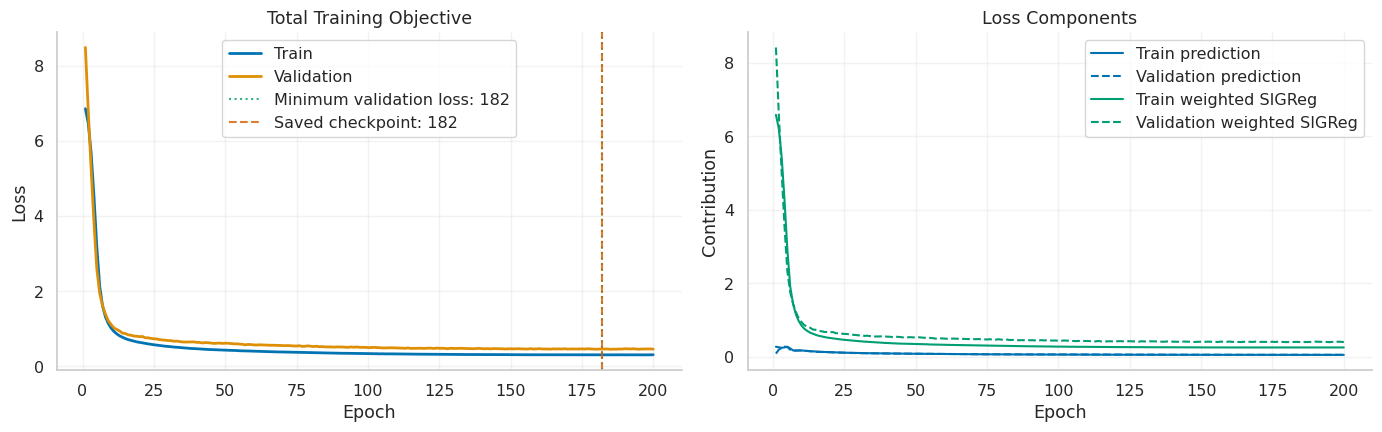

,minimum_validation_epoch,minimum_validation_prediction_loss,checkpoint_metric,checkpoint_epoch,checkpoint_validation_prediction_loss
0,182,0.056181,validation_prediction_loss,182,0.056181


In [21]:
# 分别展示历史最低验证误差与实际保存的检查点。
checkpoint_path = project_root / training_config["output_dir"] / "best.pt"
checkpoint_epoch = int(torch.load(
    checkpoint_path, map_location="cpu", weights_only=False,
)["epoch"])
training_summary, _, _ = plot_training_history(
    checkpoint_path.parent,
    sigreg_weight=training_config["sigreg_weight"],
    checkpoint_epoch=checkpoint_epoch,
)
plt.show()
display(pd.DataFrame([training_summary]))


## 状态预测评估

在单动作、多动作轨迹中筛选最长预测窗口：窗口内至少两次实际SP变化，多动作窗口至少一次同时改变多个SP。1、2、3、6步误差在同一批最长窗口上计算，因此不要求1步窗口包含两次事件。

给定真实未来动作，递归调用单步predictor，并与真实仿真观测的编码比较latent MSE。默认时长为5、10、15、30分钟；模型没有观测解码器，此处不报告物理量预测误差。评估集合由 `evaluation.split` 选择。

Latent rollout evaluation:   0%|          | 0/11 [00:00<?, ?batch/s]

数据划分：validation
检查点epoch：182
评估窗口数：2,626


,scenario_type,horizon,latent_mse_mean,latent_mse_median,latent_mse_std,window_count,horizon_minutes
0,overall,1,0.057869,0.049649,0.038162,2626,5.0
1,overall,2,0.073764,0.062295,0.048773,2626,10.0
2,overall,3,0.085253,0.071939,0.057933,2626,15.0
3,overall,6,0.116036,0.092778,0.089557,2626,30.0
4,multi_action,1,0.060196,0.052687,0.034163,1549,5.0
5,multi_action,2,0.078882,0.068563,0.045839,1549,10.0
6,multi_action,3,0.092163,0.080264,0.053385,1549,15.0
7,multi_action,6,0.127867,0.106048,0.085215,1549,30.0
8,single_action,1,0.054522,0.045821,0.043068,1077,5.0
9,single_action,2,0.066403,0.054909,0.051851,1077,10.0


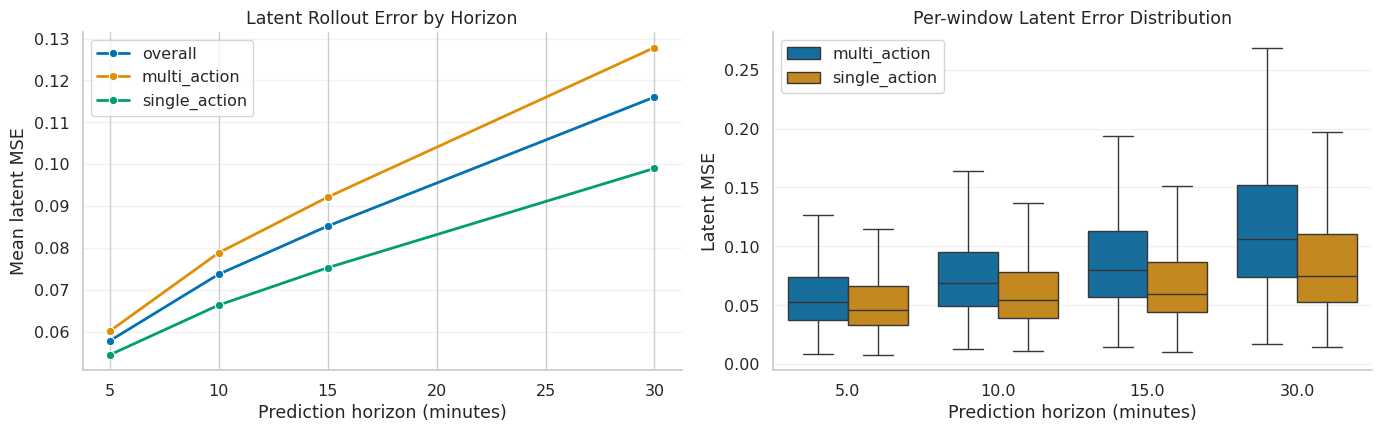

In [22]:
# 定位最佳检查点，并在验证集进行latent推演评估。
checkpoint_path = project_root / training_config["output_dir"] / "best.pt"

evaluation_config = project_config["evaluation"]
latent_evaluation = evaluate_latent_prediction(
    checkpoint_path,
    dataset_dir,
    split=evaluation_config["split"],
    scenario_types=evaluation_config["scenario_types"],
    horizons=evaluation_config["horizons"],
    batch_size=evaluation_config["batch_size"],
    device=str(device),
)

print(f"数据划分：{evaluation_config['split']}")
print(f"检查点epoch：{latent_evaluation['checkpoint_epoch']}")
print(f"评估窗口数：{latent_evaluation['window_count']:,}")
display(latent_evaluation["summary"].round(6))
plot_latent_prediction_evaluation(latent_evaluation)
plt.show()

轨迹：traj_000005
最终latent MSE：0.114702


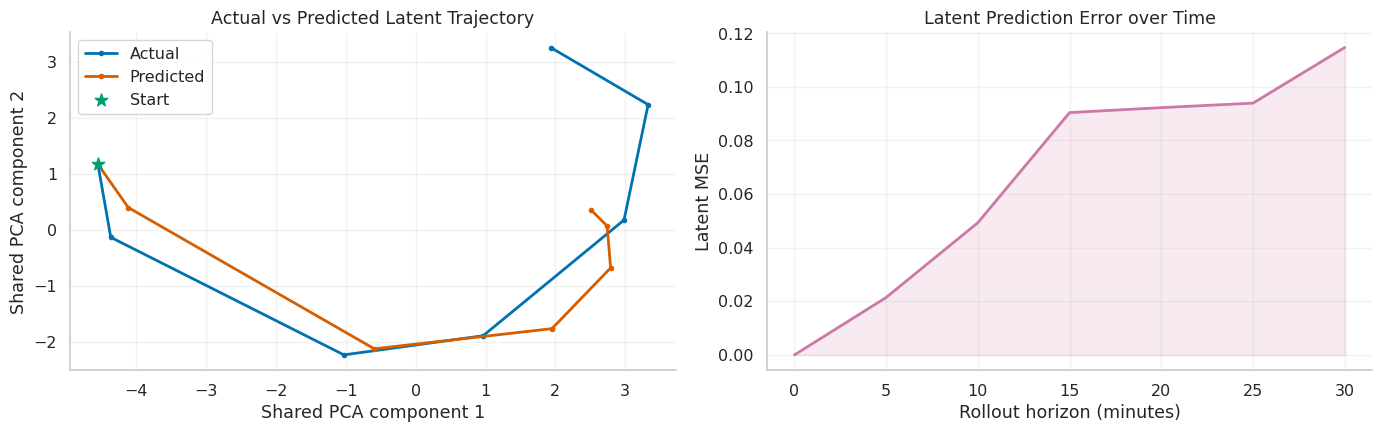

In [23]:
# 展示动作事件附近一条验证轨迹的真实与预测latent差异。
latent_trajectory = predict_latent_trajectory(
    checkpoint_path,
    dataset_dir,
    split=evaluation_config["split"],
    scenario_type="multi_action",
    horizon=max(evaluation_config["horizons"]),
    device=str(device),
)

print(f"轨迹：{latent_trajectory['trajectory_id']}")
print(f"最终latent MSE：{latent_trajectory['latent_mse'][-1]:.6f}")
plot_latent_trajectory_comparison(latent_trajectory)
plt.show()

## 控制规划任务

本节在验证集上评估“时域对齐＋SP段内保持”的CEM-MPC，不重新训练模型。按场景均分80个任务，单动作、多动作各40个；固定种子、按轨迹轮流抽取，每条轨迹最多2个任务。任务窗口至少包含两次SP变化，多动作场景须含同时改变多个SP的事件。先检查回放一致性、参考路径安全可达及保持当前SP的非平凡性。

目标取18个模型步后的真实状态，即90分钟；执行预算为20步，即100分钟。每次预测到同一个目标时刻：`H=max(1, goal_offset_steps-已执行步数)`。每执行1步（5分钟）后用真实观测重规划，目标之后采用1步预测。未提前结束时，H依次为18、17、…、2、1、1、1。

每个候选只优化一组11维SP，并在整个预测时域保持不变；实际执行期间也保持这组SP，直到下一次重规划。每次相对当前SP最多改变3个分量，各分量阶跃不超过允许范围的30%，同时满足SP上下界。模型仍每5分钟递归预测一次，SP保持不等于降低模型预测频率。

CEM仅优化末端latent目标距离，使用300候选、30精英、30轮；从训练标准化动作空间的零均值、单位标准差开始，最终返回投影后的精英均值。目标编码仍使用53维观测（XMEAS＋XMV），训练方法仍为单步latent prediction＋SIGReg。

每个模型步末检查41维XMEAS的标准化MSE是否不大于0.10；预算内到达即结束，且到达前不能停机或越软边界。软边界按每秒观测检查，不进入CEM代价，也不单独触发提前终止。参考轨迹展示至90分钟；MPC与保持动作基线使用相同的100分钟执行预算和成功判据。

验证集用于研究选参，结果保存到模型目录下的 `planning_evaluation`。本节已保存输出来自此前的5步重规划设置，需重新运行后生成当前1步重规划结果。


In [24]:
# 使用与当前模型配置一致的检查点；修改history_size后须先重新训练。
import hashlib
import json
import pickle

with open(project_root / "configs/config.yaml", encoding="utf-8") as file:
    project_config = yaml.safe_load(file)
training_config = project_config["training"]
dataset_dir = project_root / training_config["dataset_dir"]
checkpoint_path = project_root / training_config["output_dir"] / "best.pt"
planning_split = project_config["planning"]["split"]
step_minutes = model_step_seconds(project_config["data"]) / 60
settings = project_config["planning"]
print(f"初始预测时域：{settings['goal_offset_steps']}步 = {settings['goal_offset_steps'] * step_minutes:g}分钟，随后随目标剩余时间缩短")
print(f"SP整段保持；每次最多执行{settings['replan_every']}步后重规划")
print(f"执行预算：{settings['eval_budget_steps'] * step_minutes:g}分钟；到达即结束，目标时刻后采用1步反馈")
planning_evaluation = evaluate_planning_tasks(
    checkpoint_path, dataset_dir, project_config,
    split=planning_split, device="cuda" if torch.cuda.is_available() else "cpu",
)

result_dir = checkpoint_path.parent / "planning_evaluation"
result_dir.mkdir(parents=True, exist_ok=True)
planning_evaluation["summary"].to_csv(result_dir / "summary.csv", index=False)
planning_evaluation["per_task"].to_csv(result_dir / "per_task.csv", index=False)
with open(result_dir / "results.pkl", "wb") as file:
    pickle.dump(planning_evaluation, file)
provenance = {
    "config": project_config, "python": sys.executable,
    "checkpoint_sha256": hashlib.sha256(checkpoint_path.read_bytes()).hexdigest(),
    "manifest_sha256": hashlib.sha256((dataset_dir / "manifest.jsonl").read_bytes()).hexdigest(),
    "source_sha256": {name: hashlib.sha256((project_root / name).read_bytes()).hexdigest()
                       for name in ("engine/planning.py", "engine/planning_tasks.py", "engine/planning_evaluation.py", "models/model.py")},
    "screening": planning_evaluation["screening"],
}
(result_dir / "provenance.json").write_text(json.dumps(provenance, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"数据划分：{planning_evaluation['split']}")
print(f"并行设备：{planning_evaluation['devices']}")
print(f"任务筛选：{planning_evaluation['screening']}")
print(f"结果目录：{result_dir}")
display(planning_evaluation["summary"].round(4))
display(planning_evaluation["per_task"].round(4))


初始预测时域：18步 = 90分钟，随后随目标剩余时间缩短
SP整段保持；每次最多执行1步后重规划
执行预算：100分钟；到达即结束，目标时刻后采用1步反馈


CEM-MPC planning evaluation:   0%|          | 0/1317 [00:00<?, ?task/s]

数据划分：validation
并行设备：['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3', 'cuda:4', 'cuda:5', 'cuda:6', 'cuda:7']
任务筛选：{'candidate_count': 2299, 'candidate_trajectory_count': 105, 'evaluated_candidate_count': 103, 'accepted_count': 80, 'rejections': {'disallowed_outcome': 462, 'insufficient_context': 520, 'trivial_goal': 17, 'unsafe_goal': 2, 'unsafe_reference': 2, 'insufficient_action_changes': 2}, 'accepted_trajectory_count': 75, 'requested_by_scenario': {'single_action': 40, 'multi_action': 40}, 'accepted_by_scenario': {'single_action': 40, 'multi_action': 40}, 'unfilled_by_scenario': {}}
结果目录：/home/lsx/workspace/TWM/checkpoints/tep_lewm/planning_evaluation


,scenario_type,task_count,trajectory_count,success_rate,shutdown_rate,soft_limit_violation_rate,no_action_success_rate,no_action_shutdown_rate,no_action_soft_limit_violation_rate,reference_action_event_count,planned_action_event_count,planning_calls,elapsed_minutes,initial_xmeas_mse,final_xmeas_mse,oracle_xmeas_mse,no_action_xmeas_mse,mean_improvement,success_mse_threshold
0,overall,80,75,0.675,0.0125,0.0,0.0,0.0125,0.0,7.825,17.000,17.000,84.9723,1.3397,0.2042,0.0,0.4582,0.8111,0.1
1,multi_action,40,35,0.575,0.0000,0.0,0.0,0.0250,0.0,8.075,18.025,18.025,90.1250,1.3297,0.2209,0.0,0.4607,0.7732,0.1
2,single_action,40,40,0.775,0.0250,0.0,0.0,0.0000,0.0,7.575,15.975,15.975,79.8196,1.3497,0.1874,0.0,0.4557,0.8490,0.1


,trajectory_id,task_id,split,mode,start_step,replay_xmeas_mse,oracle_xmeas_mse,no_action_xmeas_mse,no_action_alive,no_action_soft_limit_violated,...,replan_every,planning_calls,initial_planning_horizon,elapsed_minutes,scenario_type,initial_xmeas_mse,final_xmeas_mse,improvement,success,alive
0,traj_000311,traj_000311:4800,validation,4,4800,0.0,0.0,0.4151,True,False,...,1,20,18,100.0,single_action,2.8878,0.2890,0.8999,False,True
1,traj_001036,traj_001036:10200,validation,5,10200,0.0,0.0,0.3423,True,False,...,1,16,18,80.0,multi_action,0.6546,0.0933,0.8574,True,True
2,traj_000030,traj_000030:3300,validation,2,3300,0.0,0.0,0.1940,True,False,...,1,12,18,60.0,single_action,0.4430,0.0621,0.8599,True,True
3,traj_001158,traj_001158:3300,validation,5,3300,0.0,0.0,0.8517,True,False,...,1,15,18,75.0,multi_action,1.5048,0.0938,0.9376,True,True
4,traj_000833,traj_000833:4800,validation,4,4800,0.0,0.0,0.2761,True,False,...,1,18,18,90.0,single_action,3.0592,0.0510,0.9833,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,traj_000360,traj_000360:5100,validation,1,5100,0.0,0.0,0.5561,True,False,...,1,19,18,95.0,single_action,1.3169,0.0611,0.9536,True,True
76,traj_000547,traj_000547:5700,validation,2,5700,0.0,0.0,0.2993,True,False,...,1,18,18,90.0,multi_action,2.4323,0.0593,0.9756,True,True
77,traj_000579,traj_000579:7200,validation,1,7200,0.0,0.0,0.3789,True,False,...,1,20,18,100.0,single_action,0.6903,0.1675,0.7574,False,True
78,traj_001135,traj_001135:3300,validation,4,3300,0.0,0.0,0.2875,True,False,...,1,18,18,90.0,multi_action,1.4316,0.0609,0.9574,True,True


轨迹：traj_001326 (multi_action)
规划成功：True
XMEAS误差改善：92.40%
实际预测时域（模型步）： [18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


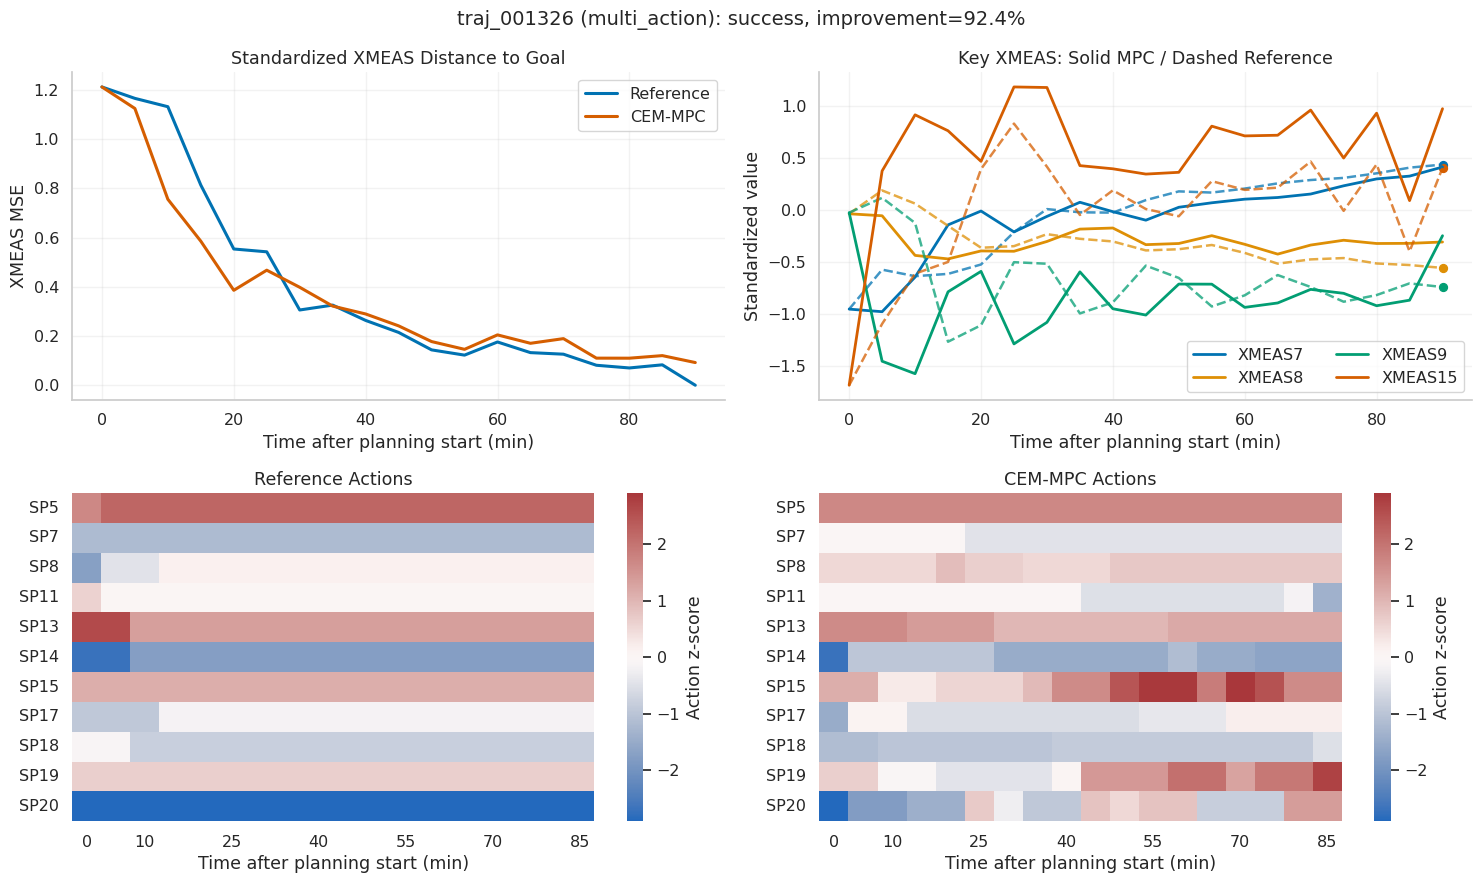

In [25]:
# 优先选择成功任务中改善程度居中的代表性案例；若均失败，则选择最具代表性的失败案例。
planning_case = planning_evaluation["typical_case"]
print(f"轨迹：{planning_case['trajectory_id']} ({planning_case['scenario_type']})")
print(f"规划成功：{planning_case['success']}")
print(f"XMEAS误差改善：{planning_case['improvement']:.2%}")
print("实际预测时域（模型步）：", planning_case["planning_horizons"].tolist())
plot_planning_case(planning_case)
plt.show()

轨迹：traj_000311 (single_action)
规划存活：True
最终XMEAS MSE：0.2890
XMEAS误差改善：89.99%


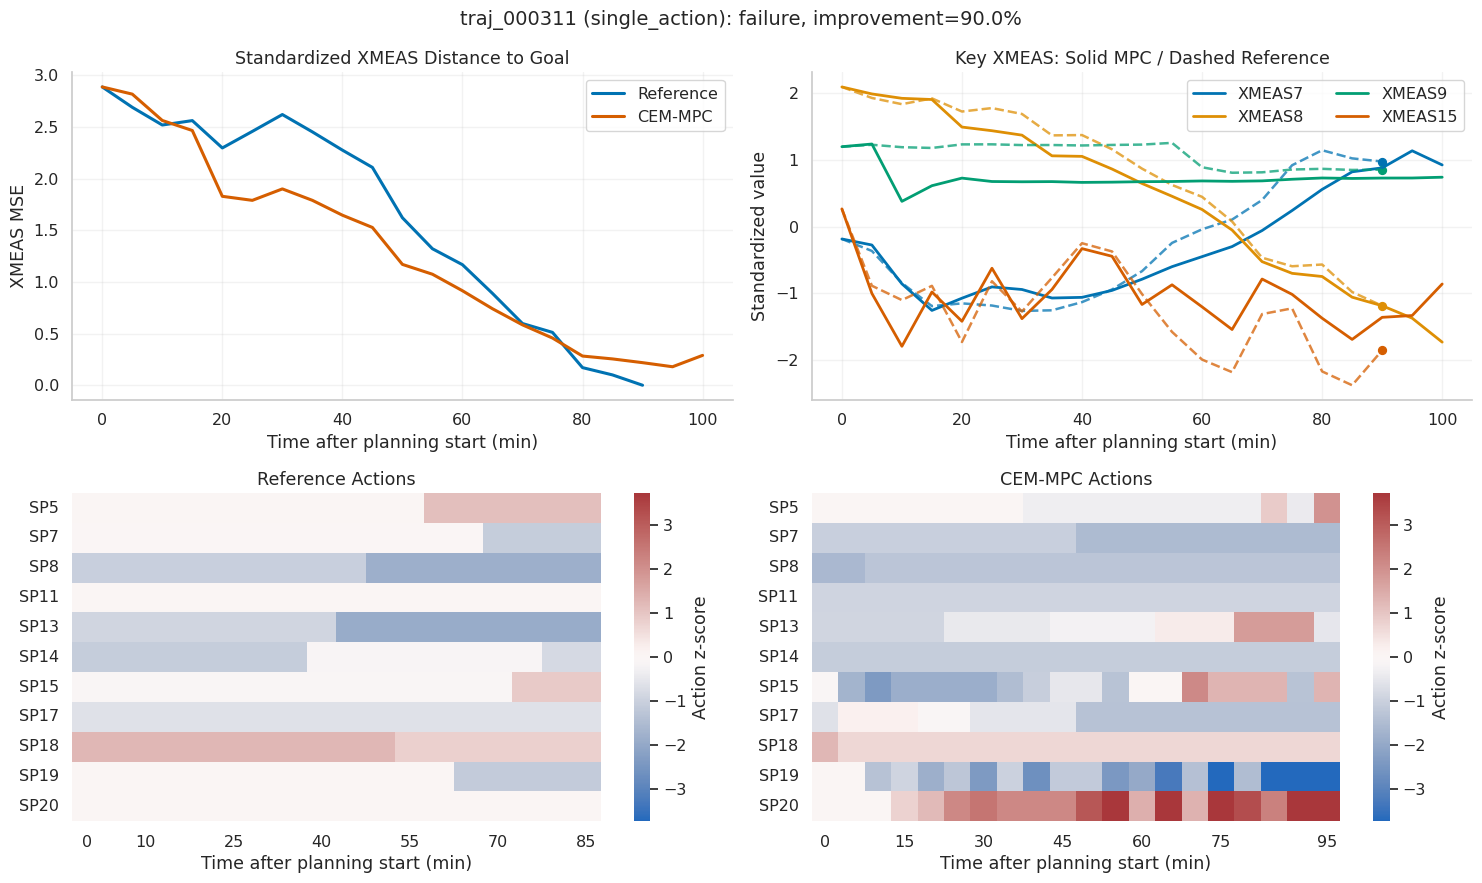

In [26]:
# 选择终点误差接近失败样本中位数的案例，观察典型失败模式。
failed_cases = [case for case in planning_evaluation["cases"] if not case["success"]]
if not failed_cases:
    print("当前评估中没有失败案例。")
else:
    failure_median = np.median([case["final_xmeas_mse"] for case in failed_cases])
    failed_planning_case = min(
        failed_cases, key=lambda case: abs(case["final_xmeas_mse"] - failure_median)
    )
    print(f"轨迹：{failed_planning_case['trajectory_id']} ({failed_planning_case['scenario_type']})")
    print(f"规划存活：{failed_planning_case['alive']}")
    print(f"最终XMEAS MSE：{failed_planning_case['final_xmeas_mse']:.4f}")
    print(f"XMEAS误差改善：{failed_planning_case['improvement']:.2%}")
    plot_planning_case(failed_planning_case)
    plt.show()

### 最终测试（方案冻结后单独执行）

研究与选参使用验证集。模型和规划方案冻结后，再单独执行本节测试，不依据测试结果调参。

以下单元读取当前配置和 `best.pt`，在配置副本中将数据划分切换为 `test_split`，不生成数据或训练模型。规划沿用时域对齐与SP段内保持：默认目标18步、预算20步，每执行1步（5分钟）后重规划，到目标时刻后继续使用1步预测。

报告1、2、3、6步latent预测误差，以及80个规划任务的成功率、停机、软越限和保持动作基线；核对测试轨迹与训练、验证轨迹无重叠。结果保存在 `checkpoints/tep_lewm/test_evaluation`，同时记录模型、数据和功能代码哈希。本节已保存的规划输出来自此前的5步重规划设置，当前1步重规划版本尚无本地测试结果。


In [27]:
# 在完成开头的依赖导入后，可单独运行本节。
import hashlib
import json
import pickle
from data.data_process import load_manifest

with open(project_root / "configs/config.yaml", encoding="utf-8") as file:
    test_config = yaml.safe_load(file)
for section in ("evaluation", "planning"):
    test_config[section]["split"] = test_config[section]["test_split"]
test_split = test_config["planning"]["split"]
assert test_split == test_config["evaluation"]["split"] == "test"
test_dataset_dir = project_root / test_config["training"]["dataset_dir"]
test_checkpoint = project_root / test_config["training"]["output_dir"] / "best.pt"
test_result_dir = test_checkpoint.parent / "test_evaluation"
test_result_dir.mkdir(parents=True, exist_ok=True)
test_device = "cuda" if torch.cuda.is_available() else "cpu"

split_ids = {
    split: {record["trajectory_id"] for record in load_manifest(test_dataset_dir, split)}
    for split in ("train", "validation", "test")
}
assert split_ids["test"].isdisjoint(split_ids["train"] | split_ids["validation"])
print("数据划分：test；测试轨迹与训练、验证轨迹无重叠")
print("各划分轨迹数：", {split: len(ids) for split, ids in split_ids.items()})
test_prediction = evaluate_latent_prediction(
    test_checkpoint, test_dataset_dir, split=test_split,
    scenario_types=test_config["evaluation"]["scenario_types"],
    horizons=test_config["evaluation"]["horizons"],
    batch_size=test_config["evaluation"]["batch_size"],
    device=test_device,
)
assert set(test_prediction["per_window"]["trajectory_id"]) <= split_ids["test"]
test_prediction["split"] = test_split
test_prediction["summary"].to_csv(test_result_dir / "prediction_summary.csv", index=False)
test_prediction["per_window"].to_csv(test_result_dir / "prediction_per_window.csv", index=False)
print(f"测试预测窗口：{test_prediction['window_count']}；模型epoch：{test_prediction['checkpoint_epoch']}")
display(test_prediction["summary"].round(6))


数据划分：test；测试轨迹与训练、验证轨迹无重叠
各划分轨迹数： {'train': 1077, 'validation': 215, 'test': 228}


Latent rollout evaluation:   0%|          | 0/11 [00:00<?, ?batch/s]

测试预测窗口：2600；模型epoch：182


,scenario_type,horizon,latent_mse_mean,latent_mse_median,latent_mse_std,window_count,horizon_minutes
0,overall,1,0.058114,0.050308,0.037913,2600,5.0
1,overall,2,0.073069,0.062913,0.047129,2600,10.0
2,overall,3,0.083920,0.071491,0.054825,2600,15.0
3,overall,6,0.114245,0.092385,0.082437,2600,30.0
4,multi_action,1,0.060759,0.053001,0.035945,1463,5.0
5,multi_action,2,0.078098,0.067607,0.044774,1463,10.0
6,multi_action,3,0.091769,0.079937,0.052639,1463,15.0
7,multi_action,6,0.129797,0.108383,0.084473,1463,30.0
8,single_action,1,0.054710,0.046969,0.040065,1137,5.0
9,single_action,2,0.066598,0.057091,0.049266,1137,10.0


In [28]:
# 固定已确定的规划协议，仅在独立测试集上评估一次。
settings = test_config["planning"]
step_minutes = model_step_seconds(test_config["data"]) / 60
print(f"测试规划：初始H={settings['goal_offset_steps']}，随后对齐剩余目标时间；SP整段保持")
print(f"每次最多执行{settings['replan_every']}步；目标距离={settings['goal_offset_steps'] * step_minutes:g}分钟，执行预算={settings['eval_budget_steps'] * step_minutes:g}分钟")
test_planning = evaluate_planning_tasks(
    test_checkpoint, test_dataset_dir, test_config,
    split=test_split, device=test_device,
)
assert test_planning["split"] == "test"
assert set(test_planning["per_task"]["split"]) == {"test"}
assert set(test_planning["per_task"]["trajectory_id"]) <= split_ids["test"]
test_planning["summary"].to_csv(test_result_dir / "planning_summary.csv", index=False)
test_planning["per_task"].to_csv(test_result_dir / "planning_per_task.csv", index=False)
with open(test_result_dir / "results.pkl", "wb") as file:
    pickle.dump({"prediction": test_prediction, "planning": test_planning}, file)
test_provenance = {
    "split": test_split, "config": test_config, "python": sys.executable,
    "checkpoint_epoch": test_prediction["checkpoint_epoch"],
    "checkpoint_sha256": hashlib.sha256(test_checkpoint.read_bytes()).hexdigest(),
    "manifest_sha256": hashlib.sha256((test_dataset_dir / "manifest.jsonl").read_bytes()).hexdigest(),
    "source_sha256": {name: hashlib.sha256((project_root / name).read_bytes()).hexdigest()
                       for name in ("engine/evaluation.py", "engine/planning.py", "engine/planning_tasks.py", "engine/planning_evaluation.py", "models/model.py")},
    "split_trajectory_counts": {split: len(ids) for split, ids in split_ids.items()},
    "test_trajectories_disjoint": True,
    "screening": test_planning["screening"],
    
}
(test_result_dir / "provenance.json").write_text(
    json.dumps(test_provenance, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("测试任务筛选：", test_planning["screening"])
print("测试设备：", test_planning["devices"])
print("结果目录：", test_result_dir)
display(test_planning["summary"].round(4))
display(test_planning["per_task"].round(4))


测试规划：初始H=18，随后对齐剩余目标时间；SP整段保持
每次最多执行1步；目标距离=90分钟，执行预算=100分钟


CEM-MPC planning evaluation:   0%|          | 0/1398 [00:00<?, ?task/s]

测试任务筛选： {'candidate_count': 2306, 'candidate_trajectory_count': 114, 'evaluated_candidate_count': 109, 'accepted_count': 80, 'rejections': {'insufficient_context': 497, 'disallowed_outcome': 411, 'insufficient_action_changes': 5, 'trivial_goal': 18, 'unsafe_reference': 5, 'unsafe_goal': 1}, 'accepted_trajectory_count': 75, 'requested_by_scenario': {'single_action': 40, 'multi_action': 40}, 'accepted_by_scenario': {'single_action': 40, 'multi_action': 40}, 'unfilled_by_scenario': {}}
测试设备： ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3', 'cuda:4', 'cuda:5', 'cuda:6', 'cuda:7']
结果目录： /home/lsx/workspace/TWM/checkpoints/tep_lewm/test_evaluation


,scenario_type,task_count,trajectory_count,success_rate,shutdown_rate,soft_limit_violation_rate,no_action_success_rate,no_action_shutdown_rate,no_action_soft_limit_violation_rate,reference_action_event_count,planned_action_event_count,planning_calls,elapsed_minutes,initial_xmeas_mse,final_xmeas_mse,oracle_xmeas_mse,no_action_xmeas_mse,mean_improvement,success_mse_threshold
0,overall,80,75,0.6125,0.0375,0.025,0.025,0.0,0.0,7.2375,17.4875,17.4875,87.3508,1.3831,0.2043,0.0,0.4104,0.8039,0.1
1,multi_action,40,35,0.5000,0.0750,0.025,0.000,0.0,0.0,7.7500,17.7250,17.7250,88.4517,1.3317,0.2810,0.0,0.4643,0.7389,0.1
2,single_action,40,40,0.7250,0.0000,0.025,0.050,0.0,0.0,6.7250,17.2500,17.2500,86.2500,1.4345,0.1276,0.0,0.3566,0.8690,0.1


,trajectory_id,task_id,split,mode,start_step,replay_xmeas_mse,oracle_xmeas_mse,no_action_xmeas_mse,no_action_alive,no_action_soft_limit_violated,...,replan_every,planning_calls,initial_planning_horizon,elapsed_minutes,scenario_type,initial_xmeas_mse,final_xmeas_mse,improvement,success,alive
0,traj_000146,traj_000146:11100,test,1,11100,0.0,0.0,0.1651,True,False,...,1,18,18,90.0,single_action,1.1688,0.0455,0.9611,True,True
1,traj_000563,traj_000563:9300,test,4,9300,0.0,0.0,0.5762,True,False,...,1,20,18,100.0,multi_action,3.1069,0.1599,0.9485,False,True
2,traj_001213,traj_001213:3300,test,5,3300,0.0,0.0,0.2887,True,False,...,1,18,18,90.0,single_action,0.8104,0.0141,0.9826,True,True
3,traj_001224,traj_001224:3600,test,2,3600,0.0,0.0,0.3382,True,False,...,1,20,18,100.0,multi_action,2.9555,0.1029,0.9652,False,True
4,traj_001134,traj_001134:3900,test,1,3900,0.0,0.0,0.2584,True,False,...,1,20,18,100.0,single_action,1.3046,0.4675,0.6416,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,traj_000912,traj_000912:4500,test,5,4500,0.0,0.0,0.4972,True,False,...,1,17,18,85.0,multi_action,1.5951,0.0706,0.9557,True,True
76,traj_000899,traj_000899:9300,test,5,9300,0.0,0.0,0.1860,True,False,...,1,18,18,90.0,multi_action,1.3865,0.0500,0.9639,True,True
77,traj_000842,traj_000842:3300,test,4,3300,0.0,0.0,0.1829,True,False,...,1,18,18,90.0,single_action,1.2094,0.0489,0.9596,True,True
78,traj_000580,traj_000580:8400,test,2,8400,0.0,0.0,0.1399,True,False,...,1,16,18,80.0,single_action,1.1010,0.0908,0.9175,True,True


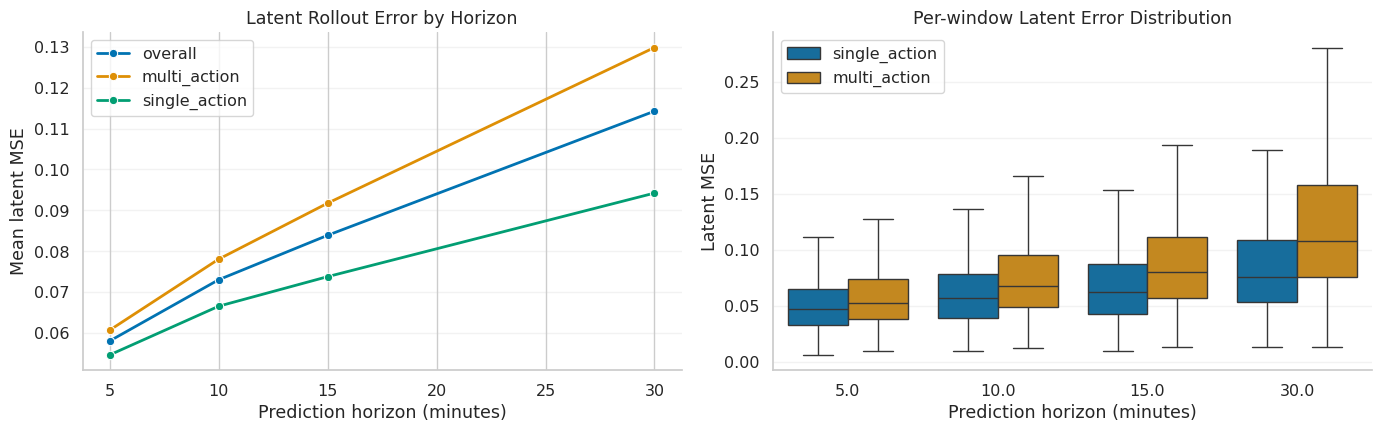

测试案例：traj_001207 (single_action)
成功：True；最终XMEAS MSE：0.0513


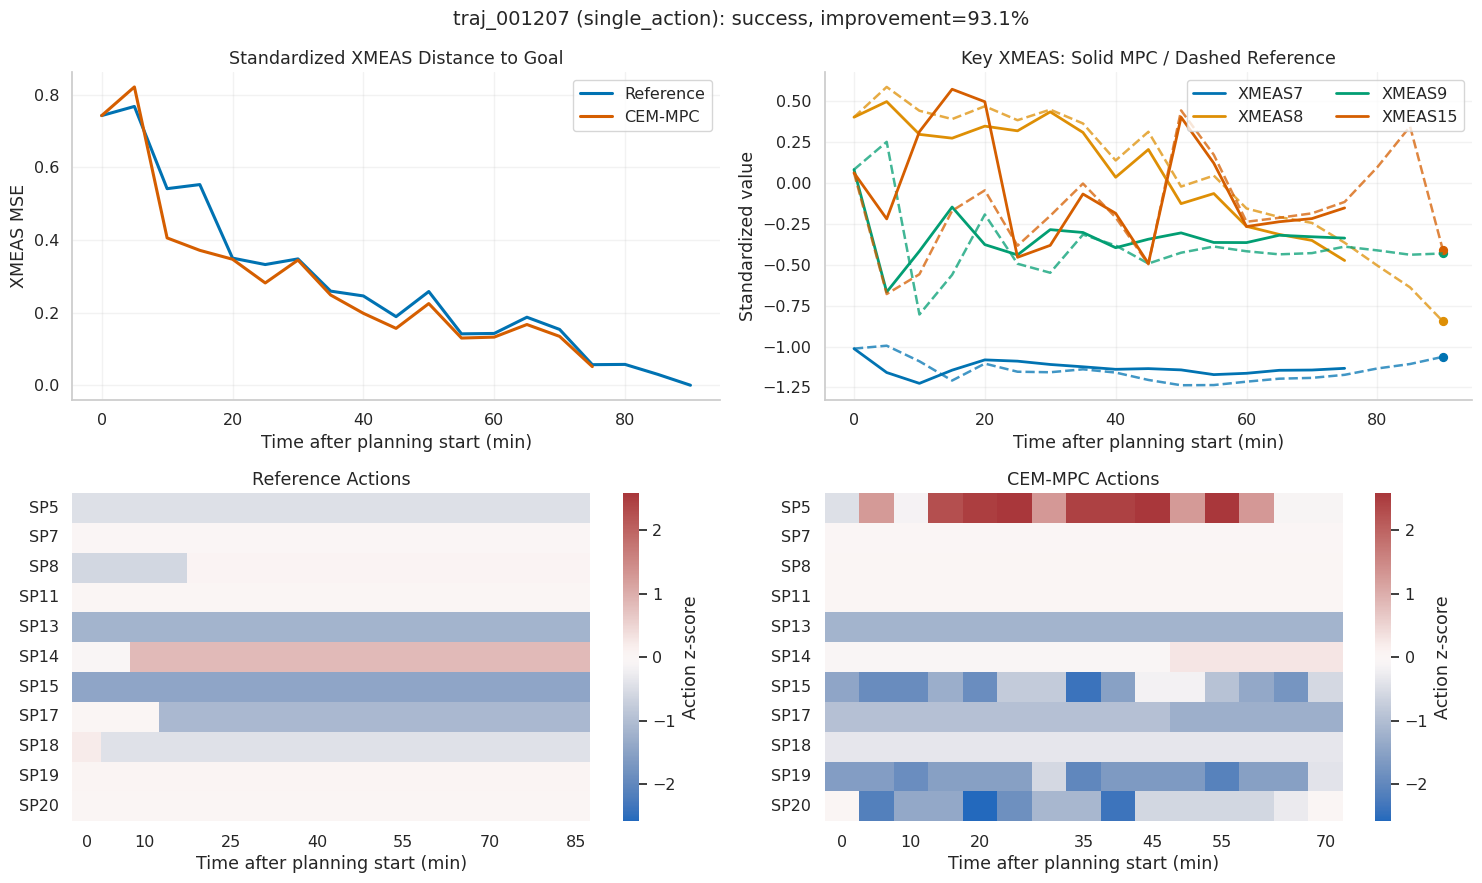

In [29]:
# 测试集预测误差与代表性规划任务。
figure, _ = plot_latent_prediction_evaluation(test_prediction)
figure.savefig(test_result_dir / "prediction.png", dpi=160)
plt.show()
test_case = test_planning["typical_case"]
print(f"测试案例：{test_case['trajectory_id']} ({test_case['scenario_type']})")
print(f"成功：{test_case['success']}；最终XMEAS MSE：{test_case['final_xmeas_mse']:.4f}")
figure, _ = plot_planning_case(test_case)
figure.savefig(test_result_dir / "planning_case.png", dpi=160)
plt.show()
